# Task 1: Denoising Autoencoder on CIFAR-10

**Goal:** train a convolutional denoising autoencoder that takes an image corrupted with Gaussian noise
and reconstructs the clean image.

Setup:
- 100 random images from the CIFAR-10 training set (labels are not used for selection, splitting or training;
  class IDs are only counted in the EDA to describe the data)
- grayscale, resized to 64x64, pixel values in [0, 1]
- 80 images for training, 20 held out for testing
- noisy input = clean + Gaussian noise, target = clean image, loss = MSE
- evaluation with MSE, PSNR and SSIM on train and test

The 20 test images are only used once, at the very end, after training is done. All hyperparameters are
fixed in advance and the model from the last epoch is evaluated, so there is no validation set, early stopping
or model selection that could leak information from the test set.

# Part 1: Setup
Libraries, random seeds, experiment settings and the compute device.

## 2. Imports

In [14]:
import os                     # folders and environment variables
import math                   # ceil, sqrt, isfinite, prod
import random                 # Python's random module (seeded for reproducibility)
import time                   # timing the training
import textwrap               # wrapping long lines in the final report

import numpy as np            # only used for seeding numpy's generator
import pandas as pd           # tables for results and statistics
import matplotlib.pyplot as plt   # all the plots

import torch                                  # tensors and autograd
import torch.nn as nn                         # layers and loss functions
import torch.nn.functional as F               # functional ops (mse_loss, conv2d)
import torchvision                            # CIFAR-10 dataset
import torchvision.transforms.functional as TF            # grayscale, resize, blur on tensors
from torchvision.transforms import InterpolationMode      # choose bicubic interpolation for resizing
from torchvision.utils import make_grid                   # put many images into one grid image
from torch.utils.data import TensorDataset, DataLoader    # wrap tensors and split into mini-batches

plt.rcParams["figure.dpi"] = 110      # resolution of figures shown in the notebook
plt.rcParams["savefig.dpi"] = 200     # higher resolution for saved figure files

OUT_DIR = "outputs"                   # figures, tables and the trained model are saved here
os.makedirs(OUT_DIR, exist_ok=True)   # create the folder (no error if it already exists)

print("torch", torch.__version__, "| torchvision", torchvision.__version__)   # record library versions

torch 2.11.0+cu130 | torchvision 0.26.0+cu130


## 3. Seeds and experiment settings

Every random step (image selection, split, noise, weight init, batch shuffling) uses a fixed seed.
The settings below are chosen before looking at any data and are not tuned on the test set.

In [15]:
SEED = 42   # master seed for the whole experiment

# needed for deterministic cuBLAS on GPU, has to be set before CUDA is first used
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

def set_seed(seed):                    # seed every random number generator we use
    random.seed(seed)                  # Python random
    np.random.seed(seed)               # NumPy random
    torch.manual_seed(seed)            # PyTorch CPU random (weight init etc.)
    torch.cuda.manual_seed_all(seed)   # PyTorch GPU random, does nothing if there is no GPU

set_seed(SEED)                                            # apply the seed now
torch.backends.cudnn.deterministic = True                 # cuDNN: always use deterministic conv algorithms
torch.backends.cudnn.benchmark = False                    # cuDNN: don't auto-pick (possibly non-deterministic) algorithms
torch.use_deterministic_algorithms(True, warn_only=True)  # prefer deterministic ops, only warn if one isn't available

N_IMAGES = 100                 # total images to select
N_TRAIN = 80                   # training images
N_TEST = N_IMAGES - N_TRAIN    # test images (20)
IMG_SIZE = 64                  # final height and width
NOISE_STD = 0.1                # std of the Gaussian noise on the [0, 1] pixel scale

BATCH_SIZE = 16                # images per mini-batch -> 5 batches per epoch
EPOCHS = 300                   # passes over the training set (fixed, no early stopping)
LR = 1e-3                      # Adam learning rate
LATENT_CH = 8                  # channels in the bottleneck

print("Random seed:", SEED)    # print the seed used for this run

Random seed: 42


## 4. Device

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # use the GPU if Colab gives us one
print("Using:", device)                                                # show which device is used
if device.type == "cuda":                                              # only when a GPU is present
    print(torch.cuda.get_device_name(0))                               # print the GPU model (e.g. Tesla T4)

Using: cuda
Tesla T4


# Part 2: Data Loading and Selection
Download CIFAR-10, randomly pick 100 images and check the selection.

## 5. Load CIFAR-10

torchvision downloads the dataset automatically. Only the image pixels are used for the experiment;
`cifar.targets` (the labels) is only read in the EDA (section 12) to count class IDs.

In [17]:
cifar = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)   # download + load the 50k training images

# cifar.data is a uint8 numpy array of shape (50000, 32, 32, 3)
all_images = torch.from_numpy(cifar.data).permute(0, 3, 1, 2)   # to tensor, channels first -> (50000, 3, 32, 32)

print("CIFAR-10 train images:", tuple(all_images.shape), all_images.dtype)   # check shape and dtype (uint8)

CIFAR-10 train images: (50000, 3, 32, 32) torch.uint8


## 6. Randomly select 100 images

A seeded random permutation of all 50,000 indices; the first 100 are kept. No class information is involved.

In [18]:
gen = torch.Generator().manual_seed(SEED)                                   # separate seeded generator for the selection
selected_idx = torch.randperm(len(all_images), generator=gen)[:N_IMAGES]    # shuffle all 50k indices, keep the first 100
images_rgb = all_images[selected_idx]                                       # the selected images, (100, 3, 32, 32) uint8

print("Selected indices:")          # document which CIFAR images were picked
print(selected_idx.tolist())        # list of the 100 indices

Selected indices:
[37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849, 25408, 33504, 27102, 21934, 40181, 47682, 45747, 17004, 43777, 7433, 45129, 37684, 14817, 38215, 30883, 19763, 14041, 46578, 19871, 39339, 39292, 8205, 47307, 15337, 45371, 20844, 26455, 25747, 21000, 49417, 42186, 49238, 25283, 78, 6899, 15568, 11143, 35952, 37965, 33436, 30770, 9583, 35210, 4856, 8020, 44859, 4191, 19421, 34688, 29312, 20326, 17740, 4894, 20621, 2614, 46726, 19045, 5668, 6159, 47718, 7907, 5294, 42872, 24855, 20370, 21209, 32223, 43179, 44262, 38506, 40214, 16895, 12328, 45173, 46138, 13520, 30459, 20165, 11227, 43731, 42697, 17911, 6857, 33366, 32393, 2860, 19849, 43759, 3139, 6468]


## 7. Data-quality checks on the selection

In [19]:
assert len(selected_idx) == N_IMAGES                                               # exactly 100 indices
assert len(torch.unique(selected_idx)) == N_IMAGES, "some index was selected twice"  # no repeated index
assert selected_idx.min() >= 0 and selected_idx.max() < len(all_images)            # all indices are valid
assert images_rgb.shape == (N_IMAGES, 3, 32, 32) and images_rgb.dtype == torch.uint8   # expected shape and type

# duplicate pictures: unique rows of the flattened images should still be 100
flat = images_rgb.flatten(1)                                      # each image as one row, (100, 3072)
n_unique_images = len(torch.unique(flat, dim=0))                  # number of distinct images
assert n_unique_images == N_IMAGES, "duplicate image content found"   # stop if two images are identical

# a constant (blank) image would have zero standard deviation
img_std = flat.float().std(dim=1)                    # pixel std of each image, (100,)
assert (img_std > 0).all(), "found a blank image"    # every image must have some variation

# same seed must give the same selection
idx_again = torch.randperm(len(all_images), generator=torch.Generator().manual_seed(SEED))[:N_IMAGES]   # redo the selection
assert torch.equal(idx_again, selected_idx)          # must be identical -> reproducible

print(f"{len(selected_idx)} images, {len(torch.unique(selected_idx))} unique indices, "
      f"{n_unique_images} unique images")                                                  # summary of the checks
print(f"index range: {selected_idx.min().item()} - {selected_idx.max().item()}")           # smallest and largest index
print(f"pixel std per image (0-255): min {img_std.min():.1f}, mean {img_std.mean():.1f}")  # contrast of the images
print("Selection checks passed.")                                                          # all asserts passed

100 images, 100 unique indices, 100 unique images
index range: 78 - 49417
pixel std per image (0-255): min 18.5, mean 53.0
Selection checks passed.


# Part 3: Data Preprocessing
Grayscale conversion, resizing to 64x64, normalisation to [0, 1] and the 80/20 train/test split.

## 8. Grayscale and resize to 64x64

`rgb_to_grayscale` uses the usual luminance weights (0.299 R + 0.587 G + 0.114 B).
Resizing 32 -> 64 uses bicubic interpolation. Note that upsampling does not add real detail.

In [20]:
gray32 = TF.rgb_to_grayscale(images_rgb)          # RGB -> 1 channel, (100, 1, 32, 32) uint8
gray64 = TF.resize(gray32, [IMG_SIZE, IMG_SIZE],
                   interpolation=InterpolationMode.BICUBIC, antialias=True)   # upsample to (100, 1, 64, 64) uint8

print("grayscale:", tuple(gray32.shape), "-> resized:", tuple(gray64.shape), gray64.dtype)   # show the shapes
assert gray64.shape == (N_IMAGES, 1, IMG_SIZE, IMG_SIZE)                                     # 1 channel, 64x64

grayscale: (100, 1, 32, 32) -> resized: (100, 1, 64, 64) torch.uint8


## 9. Normalize to [0, 1]

In [21]:
images = gray64.float() / 255.0                  # 0-255 integers -> floats in [0, 1], (100, 1, 64, 64)

print("shape:", tuple(images.shape), images.dtype)                 # (100, 1, 64, 64) float32
print(f"range: [{images.min():.3f}, {images.max():.3f}]")          # should be inside [0, 1]
assert images.min() >= 0 and images.max() <= 1                    # check the range
assert torch.isfinite(images).all()                                # no NaN or inf values

shape: (100, 1, 64, 64) torch.float32
range: [0.000, 1.000]


## 10. Train/test split (80 / 20)

A second seeded permutation decides which images go to the test set. The test images are not touched again
until section 26.

In [22]:
perm = torch.randperm(N_IMAGES, generator=torch.Generator().manual_seed(SEED + 1))   # random order of 0..99
train_pos, test_pos = perm[:N_TRAIN].sort().values, perm[N_TRAIN:].sort().values     # first 80 train, last 20 test

train_clean = images[train_pos]          # clean training images, (80, 1, 64, 64)
test_clean = images[test_pos]            # clean test images, (20, 1, 64, 64)
train_ids = selected_idx[train_pos]      # CIFAR indices of the training images (used to track what the model sees)
test_ids = selected_idx[test_pos]        # CIFAR indices of the test images

print("train:", tuple(train_clean.shape), "| test:", tuple(test_clean.shape))   # check the sizes
print("test CIFAR indices:", test_ids.tolist())                                 # document the test images

train: (80, 1, 64, 64) | test: (20, 1, 64, 64)
test CIFAR indices: [44491, 17004, 43777, 39339, 8205, 20844, 21000, 42186, 78, 6899, 8020, 19421, 2614, 47718, 42872, 24855, 32223, 16895, 20165, 43759]


## 11. Split checks

In [23]:
assert len(train_pos) == N_TRAIN and len(test_pos) == N_TEST                    # 80 / 20
assert len(set(train_pos.tolist()) & set(test_pos.tolist())) == 0               # no shared positions
assert len(set(train_ids.tolist()) & set(test_ids.tolist())) == 0               # no shared CIFAR indices
assert torch.equal(torch.cat([train_pos, test_pos]).sort().values, torch.arange(N_IMAGES))   # together they cover all 100

# no test image should have the exact same pixels as a training image
same_pixels = (test_clean.flatten(1)[:, None, :] == train_clean.flatten(1)[None, :, :]).all(dim=2)   # (20, 80) pairwise match
assert not same_pixels.any(), "a test image is identical to a training image"                        # no pixel-identical pair

perm_again = torch.randperm(N_IMAGES, generator=torch.Generator().manual_seed(SEED + 1))   # redo the split
assert torch.equal(perm_again, perm)                                                     # same seed -> same split

print("Split checks passed: 80 train / 20 test, no overlap, reproducible.")   # everything is fine

Split checks passed: 80 train / 20 test, no overlap, reproducible.


# Part 4: Exploratory Data Analysis (EDA)
Pixel statistics, dataset facts and class-ID distribution, image grids, and a train vs test comparison.

## 12. Basic EDA statistics

Edge strength = mean absolute difference between neighbouring pixels. It is a rough measure of how much
texture/detail an image has.

The second part gives general CIFAR-10 facts and counts how many selected / train / test images fall in each
class ID (0-9). Labels are only counted here for description; they played no part in selection, split or training.

,images,mean,std,min,median,max,avg contrast (per-image std),avg edge strength,% near black (<0.02),% near white (>0.98)
all,100.0,0.4656,0.2312,0.0,0.4549,1.0,0.1929,0.0280,0.6655,2.1519
train,80.0,0.4630,0.2282,0.0,0.4471,1.0,0.1903,0.0285,0.4282,1.9281
test,20.0,0.4762,0.2422,0.0,0.4824,1.0,0.2031,0.0261,1.6150,3.0469


CIFAR-10 training set: 50000 images, 10 classes, 32x32 pixels, 3 colour channels
images per class in the full set: 5000 - 5000 (balanced)
expected per class if 100 images were perfectly balanced: 10


,full set (%),selected 100,train 80,test 20
class id,,,,
0,10.0,6,4,2
1,10.0,5,3,2
2,10.0,11,7,4
3,10.0,9,8,1
4,10.0,7,7,0
5,10.0,11,8,3
6,10.0,13,10,3
7,10.0,12,11,1
8,10.0,13,11,2


classes present: selected 10/10, train 10/10, test 9/10
images per class in the selection: min 5, max 13
class IDs with no test image: [4]


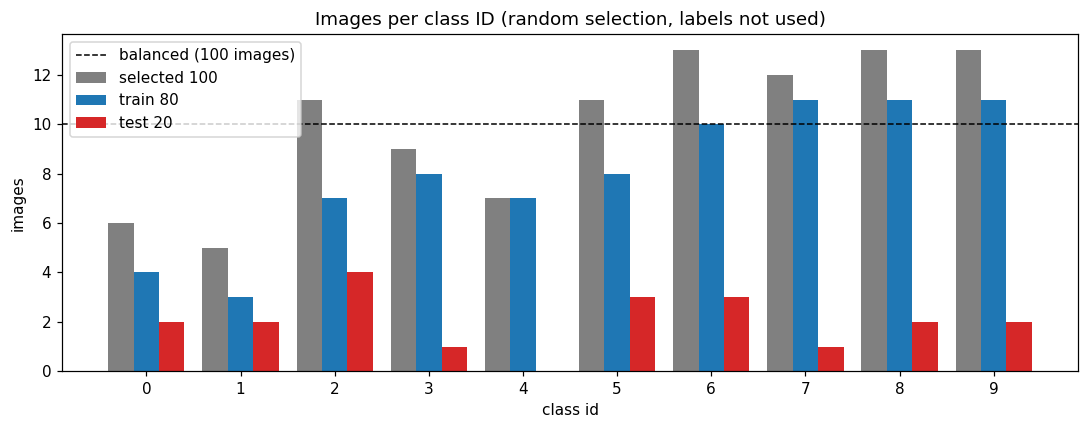

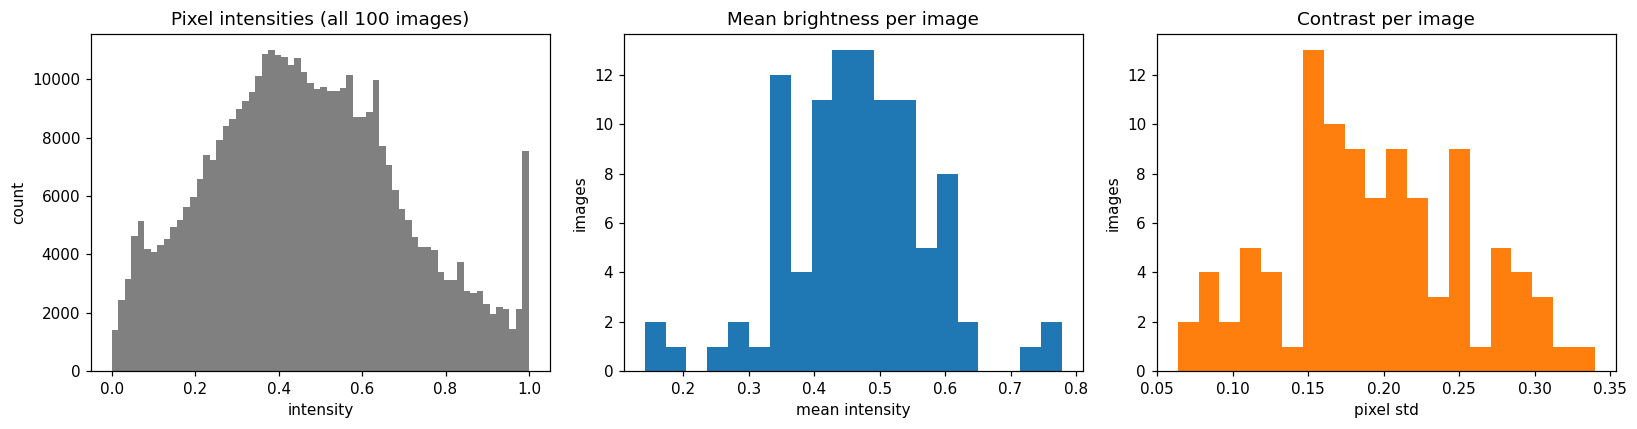

In [24]:
def edge_strength(x):                                                     # x: (N, 1, H, W) -> (N,)
    dx = (x[..., :, 1:] - x[..., :, :-1]).abs().mean(dim=(1, 2, 3))      # average horizontal pixel change per image
    dy = (x[..., 1:, :] - x[..., :-1, :]).abs().mean(dim=(1, 2, 3))      # average vertical pixel change per image
    return (dx + dy) / 2                                                  # combine both directions

def describe(x):                                       # summary statistics for a set of images
    pixels = x.flatten()                               # all pixel values in one vector
    per_img = x.flatten(1)                             # one row per image, (N, 4096)
    return {
        "images": len(x),                                                   # number of images
        "mean": pixels.mean().item(),                                       # average brightness
        "std": pixels.std().item(),                                         # spread of pixel values
        "min": pixels.min().item(),                                         # darkest pixel
        "median": pixels.median().item(),                                   # middle pixel value
        "max": pixels.max().item(),                                         # brightest pixel
        "avg contrast (per-image std)": per_img.std(dim=1).mean().item(),   # average contrast of an image
        "avg edge strength": edge_strength(x).mean().item(),                # average amount of detail
        "% near black (<0.02)": 100 * (pixels < 0.02).float().mean().item(),   # share of almost-black pixels
        "% near white (>0.98)": 100 * (pixels > 0.98).float().mean().item(),   # share of almost-white pixels
    }

eda = pd.DataFrame({"all": describe(images), "train": describe(train_clean), "test": describe(test_clean)}).T   # one row per set
display(eda.round(4))                     # show the table
eda.to_csv(f"{OUT_DIR}/eda_stats.csv")    # save it for the report

# ---- dataset facts and class distribution (class IDs only, no class names) ----
# labels are read here only to describe the data; selection, split and training were done without them
all_labels = torch.tensor(cifar.targets)                       # class ID (0-9) of every CIFAR-10 training image, (50000,)
n_classes = len(torch.unique(all_labels))                      # number of classes in CIFAR-10
full_counts = torch.bincount(all_labels, minlength=n_classes)  # images per class in the full training set

print(f"CIFAR-10 training set: {len(all_labels)} images, {n_classes} classes, "
      f"{all_images.shape[2]}x{all_images.shape[3]} pixels, {all_images.shape[1]} colour channels")   # general facts
print(f"images per class in the full set: {full_counts.min().item()} - {full_counts.max().item()} (balanced)")   # 5000 each
print(f"expected per class if 100 images were perfectly balanced: {N_IMAGES / n_classes:.0f}")                  # 10

class_counts = pd.DataFrame({
    "full set (%)": (100 * full_counts / len(all_labels)).numpy(),                                # share of each class overall
    "selected 100": torch.bincount(all_labels[selected_idx], minlength=n_classes).numpy(),       # counts in our 100 images
    "train 80": torch.bincount(all_labels[train_ids], minlength=n_classes).numpy(),              # counts in the training set
    "test 20": torch.bincount(all_labels[test_ids], minlength=n_classes).numpy(),                # counts in the test set
}, index=pd.Index(range(n_classes), name="class id"))                                            # one row per class ID
display(class_counts)                                       # show the table
class_counts.to_csv(f"{OUT_DIR}/class_distribution.csv")    # save it

classes_in_selection = int((class_counts["selected 100"] > 0).sum())   # how many classes appear in the 100 images
classes_in_test = int((class_counts["test 20"] > 0).sum())             # how many classes appear in the test set
print(f"classes present: selected {classes_in_selection}/{n_classes}, "
      f"train {int((class_counts['train 80'] > 0).sum())}/{n_classes}, test {classes_in_test}/{n_classes}")   # coverage
print(f"images per class in the selection: min {class_counts['selected 100'].min()}, "
      f"max {class_counts['selected 100'].max()}")           # how uneven the random selection is
missing_test = class_counts.index[class_counts["test 20"] == 0].tolist()   # class IDs with no test image
if missing_test:                                             # only print if some class is missing
    print("class IDs with no test image:", missing_test)

fig, ax = plt.subplots(figsize=(10, 4))                      # one grouped bar chart
x = torch.arange(n_classes).numpy()                          # bar positions, one group per class
for k, (col, color) in enumerate([("selected 100", "gray"), ("train 80", "tab:blue"), ("test 20", "tab:red")]):   # 3 bars per class
    ax.bar(x + (k - 1) * 0.27, class_counts[col], width=0.27, color=color, label=col)                             # shift bars side by side
ax.axhline(N_IMAGES / n_classes, color="k", ls="--", lw=1, label="balanced (100 images)")   # reference line at 10
ax.set_xticks(x)                                             # one tick per class
ax.set(title="Images per class ID (random selection, labels not used)", xlabel="class id", ylabel="images")   # labels
ax.legend()                                                  # legend
fig.tight_layout()                                           # tidy spacing
fig.savefig(f"{OUT_DIR}/class_distribution.png", bbox_inches="tight")   # save
plt.show()                                                   # display

fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                          # three plots side by side
axes[0].hist(images.flatten().numpy(), bins=64, color="gray")                            # histogram of all pixel values
axes[0].set(title="Pixel intensities (all 100 images)", xlabel="intensity", ylabel="count")   # labels
axes[1].hist(images.flatten(1).mean(1).numpy(), bins=20, color="tab:blue")               # brightness of each image
axes[1].set(title="Mean brightness per image", xlabel="mean intensity", ylabel="images")  # labels
axes[2].hist(images.flatten(1).std(1).numpy(), bins=20, color="tab:orange")              # contrast of each image
axes[2].set(title="Contrast per image", xlabel="pixel std", ylabel="images")             # labels
fig.tight_layout()                                                                       # avoid overlapping labels
fig.savefig(f"{OUT_DIR}/eda_histograms.png", bbox_inches="tight")                        # save the figure
plt.show()                                                                               # display it

## 13. Visual EDA

All selected images (train and test shown separately), and a few examples of the preprocessing steps.

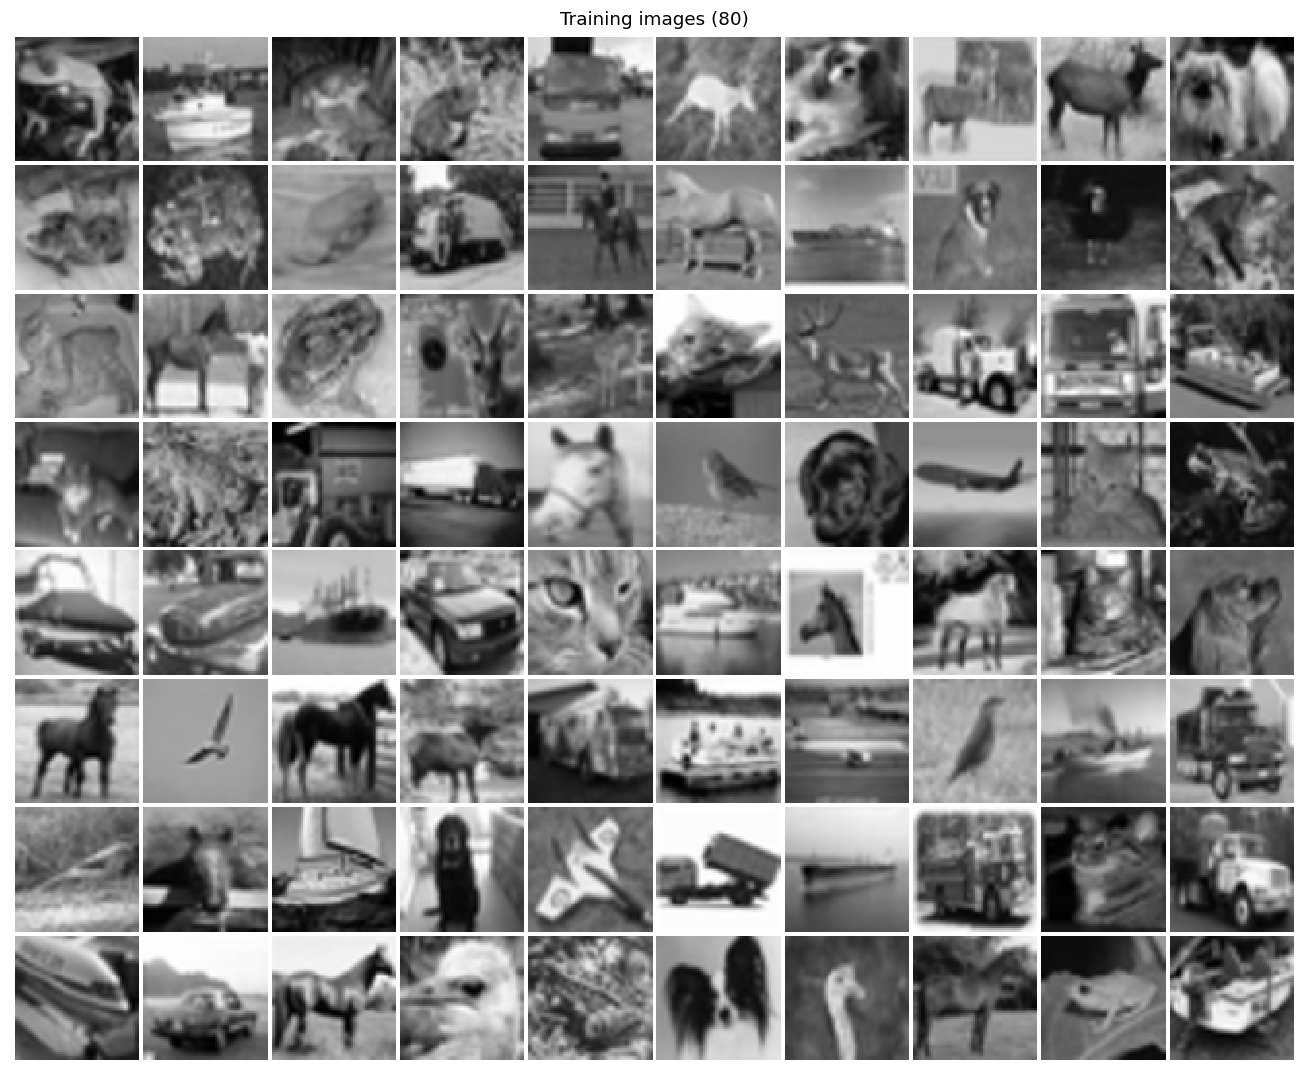

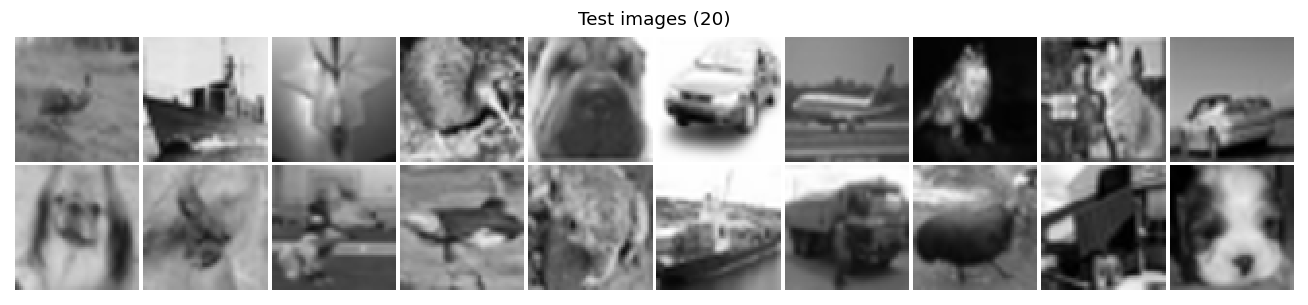

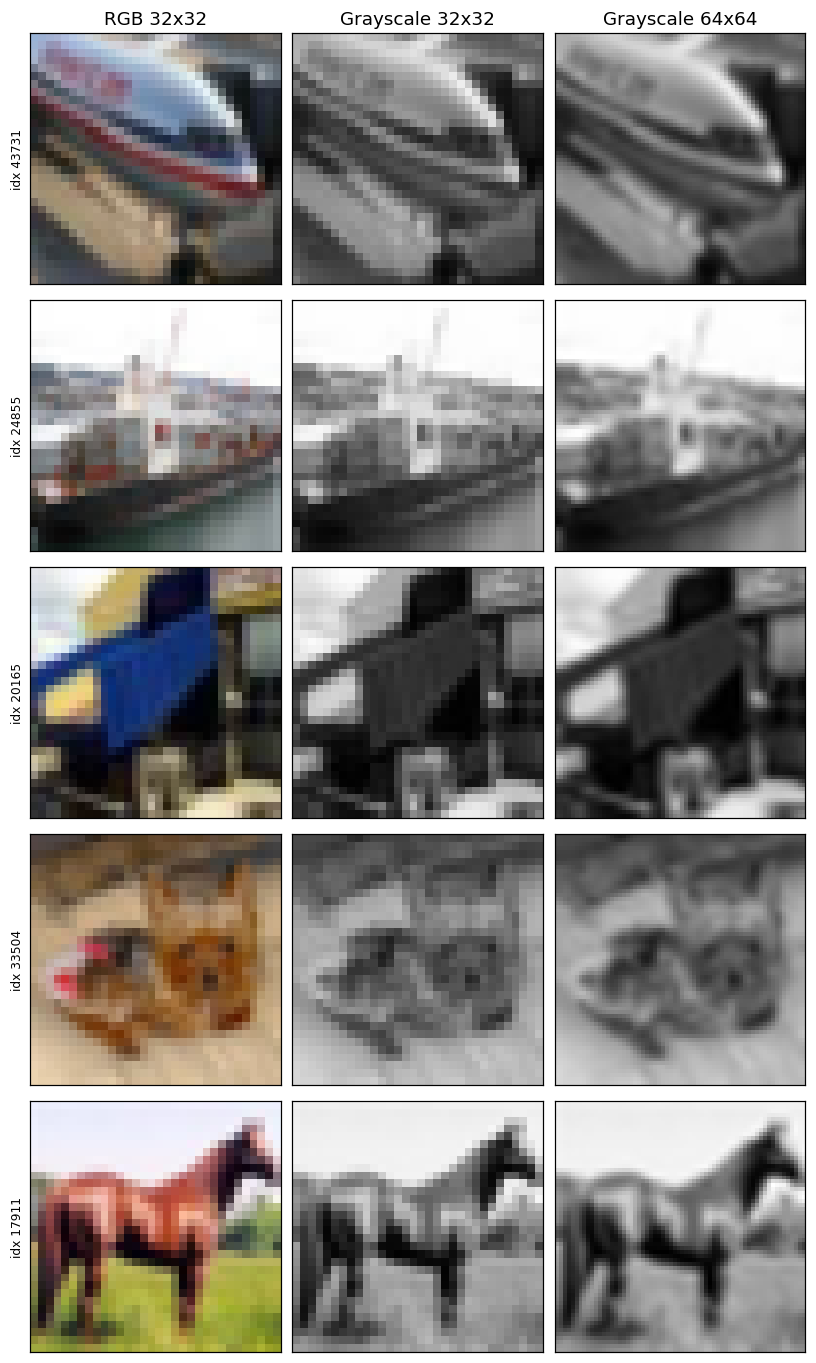

In [25]:
def show_grid(x, nrow, title, fname):                              # show many images as one grid
    grid = make_grid(x, nrow=nrow, padding=2, pad_value=1.0)       # (3, H, W), grayscale repeated to 3 channels, white borders
    plt.figure(figsize=(nrow * 1.2, math.ceil(len(x) / nrow) * 1.2 + 0.4))   # size depends on the number of rows
    plt.imshow(grid.permute(1, 2, 0).numpy(), interpolation="nearest")       # matplotlib wants (H, W, 3)
    plt.title(title)                                                # figure title
    plt.axis("off")                                                 # no axes for images
    plt.tight_layout()                                              # remove extra spacing
    plt.savefig(f"{OUT_DIR}/{fname}", bbox_inches="tight")          # save the figure
    plt.show()                                                      # display it

show_grid(train_clean, 10, "Training images (80)", "eda_train_images.png")   # all training images, 10 per row
show_grid(test_clean, 10, "Test images (20)", "eda_test_images.png")         # all test images, 10 per row

# preprocessing steps for 5 random images
examples = torch.randperm(N_IMAGES, generator=torch.Generator().manual_seed(SEED + 10))[:5]   # 5 random images (seeded)
fig, axes = plt.subplots(len(examples), 3, figsize=(7.5, 2.5 * len(examples)))              # one row per example, 3 stages
for r, i in enumerate(examples):                                                             # r = row, i = image position
    axes[r, 0].imshow(images_rgb[i].permute(1, 2, 0).numpy(), interpolation="nearest")       # original colour image
    axes[r, 1].imshow(gray32[i, 0].numpy(), cmap="gray", vmin=0, vmax=255, interpolation="nearest")   # grayscale 32x32
    axes[r, 2].imshow(gray64[i, 0].numpy(), cmap="gray", vmin=0, vmax=255, interpolation="nearest")   # grayscale 64x64
    axes[r, 0].set_ylabel(f"idx {selected_idx[i].item()}", fontsize=8)                        # CIFAR index as row label
    for ax in axes[r]:                                                                       # every panel in this row
        ax.set_xticks([]); ax.set_yticks([])                                                 # hide tick marks
for c, t in enumerate(["RGB 32x32", "Grayscale 32x32", "Grayscale 64x64"]):                  # column titles
    axes[0, c].set_title(t)                                                                  # put them on the first row
fig.tight_layout()                                                                           # tidy spacing
fig.savefig(f"{OUT_DIR}/eda_preprocessing.png", bbox_inches="tight")                         # save the figure
plt.show()                                                                                   # display it

## 14. Train vs test pixel statistics

Quick check that the 20 test images look roughly like the 80 training images. With only 20 test images
some difference is expected just by chance.

,train mean,test mean,train std,test std,test - train (%)
brightness,0.4630,0.4762,0.1110,0.1202,2.8611
contrast,0.1903,0.2031,0.0613,0.0625,6.7098
edge strength,0.0285,0.0261,0.0086,0.0076,-8.5123


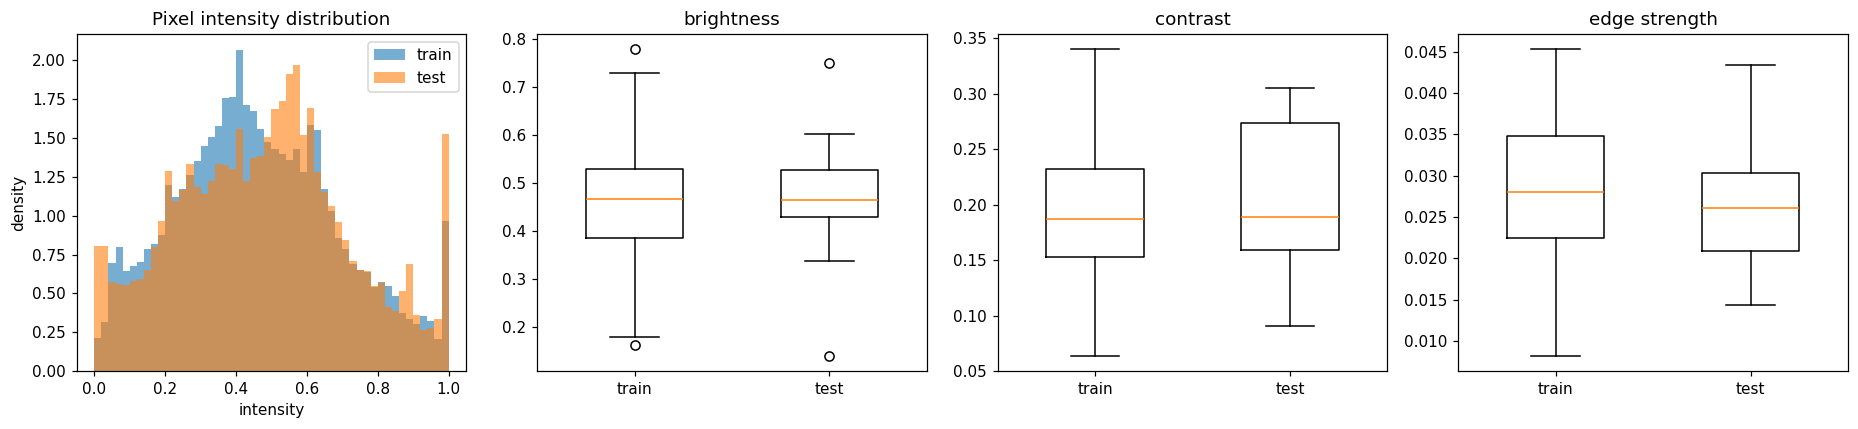

In [26]:
def image_features(x):                                      # per-image features as a table
    return pd.DataFrame({
        "brightness": x.flatten(1).mean(1).numpy(),         # mean pixel value of each image
        "contrast": x.flatten(1).std(1).numpy(),            # pixel std of each image
        "edge strength": edge_strength(x).numpy(),          # amount of detail of each image
    })

train_feat = image_features(train_clean)    # 80 rows
test_feat = image_features(test_clean)      # 20 rows

compare = pd.DataFrame({
    "train mean": train_feat.mean(), "test mean": test_feat.mean(),   # average feature value per set
    "train std": train_feat.std(), "test std": test_feat.std(),       # spread of the feature per set
})
compare["test - train (%)"] = 100 * (compare["test mean"] - compare["train mean"]) / compare["train mean"]   # relative difference
display(compare.round(4))                              # show the comparison
compare.to_csv(f"{OUT_DIR}/train_vs_test_stats.csv")  # save it

fig, axes = plt.subplots(1, 4, figsize=(17, 4))                                                     # 4 panels
axes[0].hist(train_clean.flatten().numpy(), bins=50, density=True, alpha=0.6, label="train")        # train pixel distribution
axes[0].hist(test_clean.flatten().numpy(), bins=50, density=True, alpha=0.6, label="test")          # test pixel distribution (density so sizes don't matter)
axes[0].set(title="Pixel intensity distribution", xlabel="intensity", ylabel="density")             # labels
axes[0].legend()                                                                                    # legend
for ax, col in zip(axes[1:], train_feat.columns):           # one boxplot per feature
    ax.boxplot([train_feat[col], test_feat[col]], widths=0.5)   # train vs test box
    ax.set_xticks([1, 2])                                   # two boxes
    ax.set_xticklabels(["train", "test"])                   # name them
    ax.set_title(col)                                       # feature name
fig.tight_layout()                                                       # tidy spacing
fig.savefig(f"{OUT_DIR}/train_vs_test_stats.png", bbox_inches="tight")   # save
plt.show()                                                               # display

# Part 5: Noise Generation
Create the noisy inputs, check the noise statistics and visualise clean vs noisy images.

## 15. Gaussian noise

`noisy = clamp(clean + N(0, sigma^2), 0, 1)`. Each image gets one fixed noise sample, generated with its own
seeded generator so the noise is the same in every run.

In [27]:
def add_noise(x, std, seed):                                 # add reproducible Gaussian noise to a batch of images
    g = torch.Generator().manual_seed(seed)                  # private seeded generator
    noise = torch.randn(x.shape, generator=g) * std          # N(0, 1) samples scaled to N(0, std^2), same shape as x
    noisy = (x + noise).clamp(0, 1)                          # add noise and keep pixels in [0, 1]
    return noise, noisy                                      # raw noise (for analysis) and noisy images (model input)

TRAIN_NOISE_SEED, TEST_NOISE_SEED = SEED + 2, SEED + 3                            # different seeds for train and test noise
train_noise, train_noisy = add_noise(train_clean, NOISE_STD, TRAIN_NOISE_SEED)   # (80, 1, 64, 64) each
test_noise, test_noisy = add_noise(test_clean, NOISE_STD, TEST_NOISE_SEED)       # (20, 1, 64, 64) each

print("noise std:", NOISE_STD)                                                              # noise level used
print("train noisy:", tuple(train_noisy.shape), "| test noisy:", tuple(test_noisy.shape))   # shapes
assert train_noisy.min() >= 0 and train_noisy.max() <= 1                                    # clamping worked

noise std: 0.1
train noisy: (80, 1, 64, 64) | test noisy: (20, 1, 64, 64)


## 16. Noise statistics

The generated noise should have mean ~0, std ~sigma, skewness ~0 and excess kurtosis ~0 (Gaussian).
The MSE of the noisy images is the "do nothing" baseline the model has to beat.

,raw noise,after clamping,expected
mean,-0.00019,-0.00023,0.0
std,0.09980,0.09686,0.1
skewness,-0.00109,0.01942,0.0
excess kurtosis,-0.00464,0.03649,0.0


pixels clipped: 4.29%
expected MSE without clipping (sigma^2): 0.010000
noisy input MSE  train: 0.009409  test: 0.009275


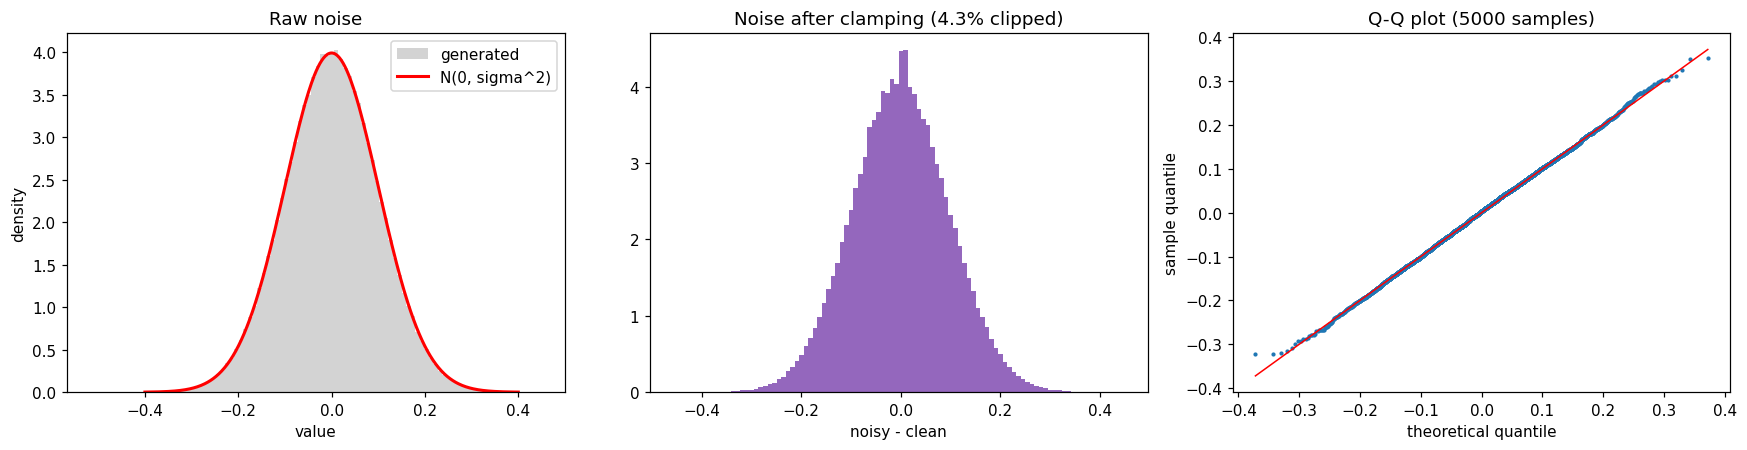

In [28]:
noise_all = torch.cat([train_noise, test_noise]).flatten()    # all raw noise values (409,600)
clean_all = torch.cat([train_clean, test_clean]).flatten()    # matching clean pixels
noisy_all = torch.cat([train_noisy, test_noisy]).flatten()    # matching noisy pixels
effective = noisy_all - clean_all                             # noise left after clamping

def moments(v):                                    # mean, std, skewness and kurtosis of a vector
    z = (v - v.mean()) / v.std()                   # standardise to mean 0, std 1
    return {"mean": v.mean().item(), "std": v.std().item(),
            "skewness": (z ** 3).mean().item(),               # asymmetry, 0 for a Gaussian
            "excess kurtosis": (z ** 4).mean().item() - 3}    # tail heaviness, 0 for a Gaussian

noise_table = pd.DataFrame({
    "raw noise": moments(noise_all),                     # noise as generated
    "after clamping": moments(effective),                # noise actually in the inputs
    "expected": {"mean": 0.0, "std": NOISE_STD, "skewness": 0.0, "excess kurtosis": 0.0},   # theory
})
display(noise_table.round(5))                          # show the table
noise_table.to_csv(f"{OUT_DIR}/noise_stats.csv")       # save it

clipped = ((clean_all + noise_all < 0) | (clean_all + noise_all > 1)).float().mean().item()   # share of pixels that got clamped
print(f"pixels clipped: {100 * clipped:.2f}%")                                               # print it as a percentage

train_noisy_mse = F.mse_loss(train_noisy, train_clean).item()   # error if the model just returned its input (train)
test_noisy_mse = F.mse_loss(test_noisy, test_clean).item()      # same for test
print(f"expected MSE without clipping (sigma^2): {NOISE_STD ** 2:.6f}")                 # theory: MSE = sigma^2
print(f"noisy input MSE  train: {train_noisy_mse:.6f}  test: {test_noisy_mse:.6f}")     # measured values

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))                                       # 3 panels
xs = torch.linspace(-4 * NOISE_STD, 4 * NOISE_STD, 400)                                 # x values for the Gaussian curve
pdf = torch.exp(-xs ** 2 / (2 * NOISE_STD ** 2)) / (NOISE_STD * math.sqrt(2 * math.pi))   # Gaussian density formula
axes[0].hist(noise_all.numpy(), bins=100, density=True, color="lightgray", label="generated")   # histogram of the noise
axes[0].plot(xs.numpy(), pdf.numpy(), "r", lw=2, label="N(0, sigma^2)")                         # theoretical curve on top
axes[0].set(title="Raw noise", xlabel="value", ylabel="density")                                # labels
axes[0].legend()                                                                                # legend

axes[1].hist(effective.numpy(), bins=100, density=True, color="tab:purple")                    # noise after clamping
axes[1].set(title=f"Noise after clamping ({100 * clipped:.1f}% clipped)", xlabel="noisy - clean")   # labels

# Q-Q plot: sorted noise samples vs theoretical normal quantiles
sample = noise_all[torch.randperm(len(noise_all), generator=torch.Generator().manual_seed(SEED + 11))[:5000]]   # 5000 random noise values
sample = sample.sort().values                                          # sorted -> sample quantiles
probs = (torch.arange(1, 5001) - 0.5) / 5000                           # matching probability levels
theory = torch.distributions.Normal(0.0, NOISE_STD).icdf(probs)        # Gaussian quantiles at those levels
axes[2].scatter(theory.numpy(), sample.numpy(), s=3)                   # points on the red line = Gaussian
axes[2].plot(theory.numpy(), theory.numpy(), "r", lw=1)                # reference line y = x
axes[2].set(title="Q-Q plot (5000 samples)", xlabel="theoretical quantile", ylabel="sample quantile")   # labels
fig.tight_layout()                                                     # tidy spacing
fig.savefig(f"{OUT_DIR}/noise_analysis.png", bbox_inches="tight")      # save
plt.show()                                                             # display

## 17. Clean / noise / noisy examples

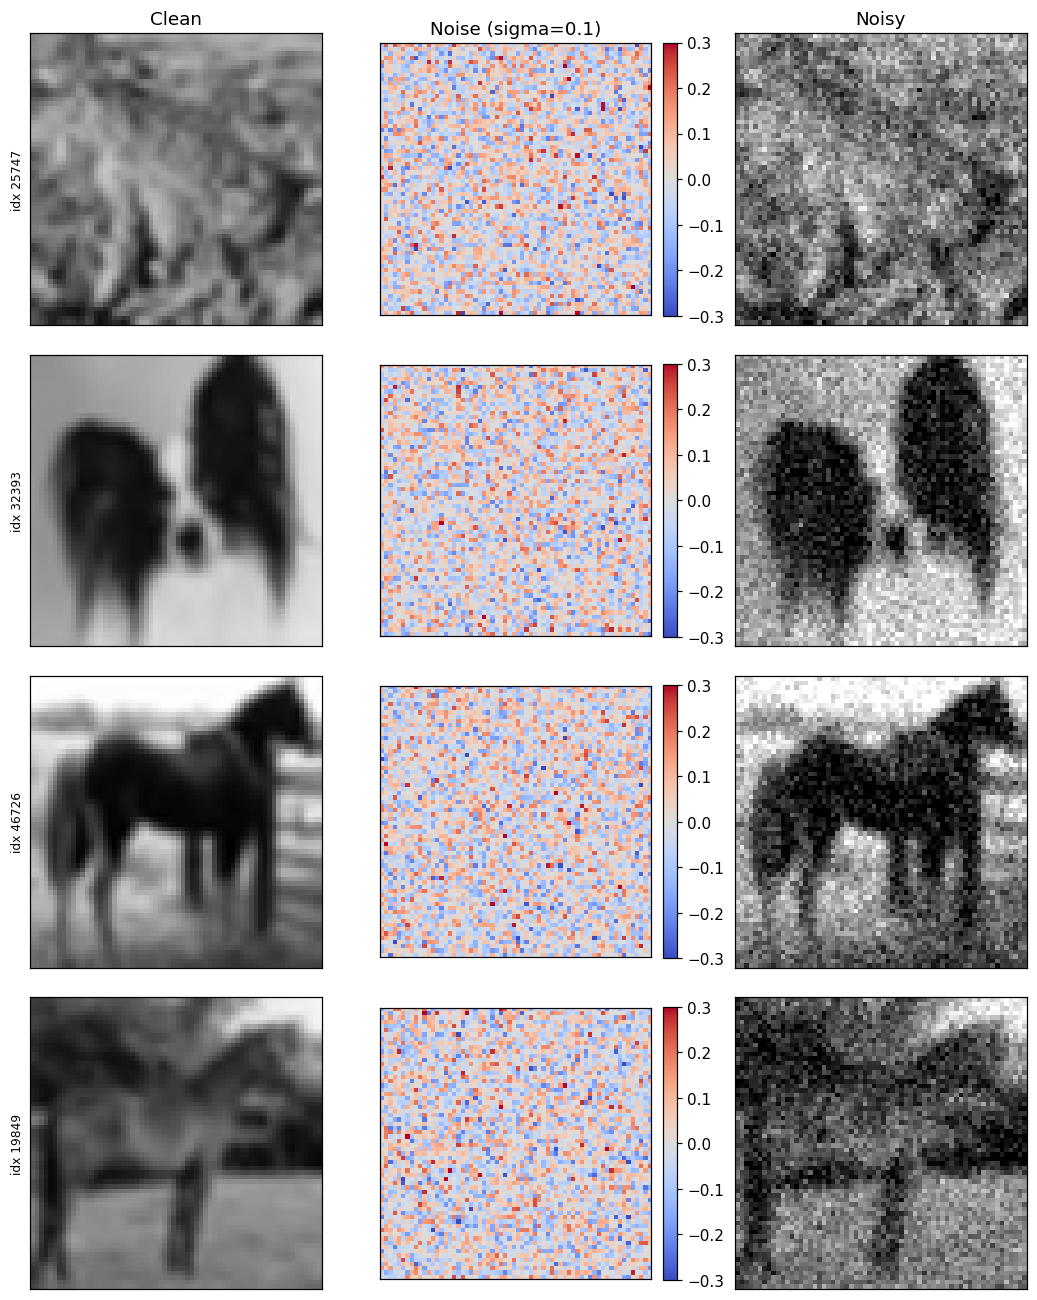

In [29]:
show = torch.randperm(N_TRAIN, generator=torch.Generator().manual_seed(SEED + 12))[:4]   # 4 random training images
fig, axes = plt.subplots(len(show), 3, figsize=(9.5, 3 * len(show)))                     # one row per image
for r, i in enumerate(show):                                                             # r = row, i = image
    axes[r, 0].imshow(train_clean[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)            # clean image
    im = axes[r, 1].imshow(train_noise[i, 0].numpy(), cmap="coolwarm", vmin=-3 * NOISE_STD, vmax=3 * NOISE_STD)   # noise (blue = darker, red = brighter)
    axes[r, 2].imshow(train_noisy[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)            # noisy image
    fig.colorbar(im, ax=axes[r, 1], fraction=0.046, pad=0.04)                            # colour scale for the noise
    axes[r, 0].set_ylabel(f"idx {train_ids[i].item()}", fontsize=8)                      # CIFAR index
    for ax in axes[r]:                                                                   # every panel in the row
        ax.set_xticks([]); ax.set_yticks([])                                             # hide ticks
axes[0, 0].set_title("Clean")                                 # column titles
axes[0, 1].set_title(f"Noise (sigma={NOISE_STD})")
axes[0, 2].set_title("Noisy")
fig.tight_layout()                                                       # tidy spacing
fig.savefig(f"{OUT_DIR}/clean_noise_noisy.png", bbox_inches="tight")     # save
plt.show()                                                               # display

# Part 6: Model Building and Training
DataLoaders, the denoising autoencoder, training setup, the training loop and the loss curve.

## 18. DataLoaders

Each sample is `(noisy, clean, cifar_index)`. The index is only used to verify that no test image is ever
passed through the training loop.

In [30]:
train_ds = TensorDataset(train_noisy, train_clean, train_ids)   # 80 samples of (input, target, id)
test_ds = TensorDataset(test_noisy, test_clean, test_ids)       # 20 samples, only used at the end

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED + 4))   # shuffled batches of 16, seeded order
train_eval_loader = DataLoader(train_ds, batch_size=N_TRAIN, shuffle=False)    # whole train set in one batch, fixed order
test_loader = DataLoader(test_ds, batch_size=N_TEST, shuffle=False)            # whole test set in one batch, fixed order

xb, yb, ib = next(iter(train_eval_loader))                                       # grab one batch to inspect
print("batches per epoch:", len(train_loader))                                   # 80 / 16 = 5
print("input:", tuple(xb.shape), "| target:", tuple(yb.shape), "| ids:", tuple(ib.shape))   # batch shapes

batches per epoch: 5
input: (80, 1, 64, 64) | target: (80, 1, 64, 64) | ids: (80,)


## 19. Denoising autoencoder

Encoder: 1x64x64 -> 8x16x16 (2048 values, half the size of the input).
Decoder: 8x16x16 -> 1x64x64. No skip connections, so everything has to go through the bottleneck.

In [31]:
class DenoisingAE(nn.Module):                         # our model, built on PyTorch's Module class
    def __init__(self, latent_ch=LATENT_CH):          # latent_ch = channels in the bottleneck
        super().__init__()                            # set up the nn.Module internals
        self.encoder = nn.Sequential(                 # layers run one after another
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(inplace=True),              # 32 filters 3x3 -> (B, 32, 64, 64)
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),   # stride 2 halves the size -> (B, 64, 32, 32)
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),             # more features, same size -> (B, 64, 32, 32)
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(inplace=True),  # halve again -> (B, 128, 16, 16)
            nn.Conv2d(128, latent_ch, 1),                                       # 1x1 conv squeezes channels -> (B, 8, 16, 16) bottleneck
        )
        self.decoder = nn.Sequential(                 # mirror of the encoder
            nn.Conv2d(latent_ch, 128, 1), nn.ReLU(inplace=True),                         # expand channels -> (B, 128, 16, 16)
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(inplace=True),  # upsample x2 -> (B, 64, 32, 32)
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),                      # refine -> (B, 64, 32, 32)
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(inplace=True),   # upsample x2 -> (B, 32, 64, 64)
            nn.Conv2d(32, 1, 3, padding=1),                                              # back to 1 channel -> (B, 1, 64, 64)
            nn.Sigmoid(),                                                                # squash outputs into (0, 1)
        )

    def forward(self, x):          # x: noisy images (B, 1, 64, 64)
        z = self.encoder(x)        # compress to the latent code (B, 8, 16, 16)
        return self.decoder(z)     # rebuild the image (B, 1, 64, 64)

# Notes on the layers:
# - stride=2 convolutions halve the height/width (downsampling)
# - ConvTranspose2d(k=4, s=2, p=1) doubles height/width: out = (in - 1) * 2 - 2 + 4 = 2 * in
# - the 1x1 convs only change the number of channels (compress to 8, expand back to 128)
# - ReLU(x) = max(0, x) is the non-linearity between layers
# - Sigmoid at the end keeps predictions in the same [0, 1] range as the clean images

## 20. Model summary

In [32]:
set_seed(SEED)                      # reseed so the initial weights are the same every run
model = DenoisingAE().to(device)    # build the model and move it to GPU/CPU
print(model)                        # print all layers

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)                  # count trainable weights
print(f"\ntrainable parameters: {n_params:,}  (~{n_params // N_TRAIN:,} per training image)")   # many params per image = risk of overfitting

# pass a dummy batch through to check the shapes layer by layer
with torch.no_grad():                                              # no gradients needed here
    h = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE, device=device)       # fake batch of 2 images
    print("\ninput", tuple(h.shape))                               # (2, 1, 64, 64)
    for name, part in [("enc", model.encoder), ("dec", model.decoder)]:   # go through encoder, then decoder
        for layer in part:                                         # each layer in turn
            h = layer(h)                                           # apply it
            if not isinstance(layer, (nn.ReLU, nn.Sigmoid)):       # activations don't change the shape, skip them
                print(f"{name} {layer.__class__.__name__:<16} -> {tuple(h.shape)}")   # layer type and output shape
        if name == "enc":                                          # right after the encoder
            latent_shape = tuple(h.shape[1:])                      # remember the bottleneck shape (8, 16, 16)

latent_size = math.prod(latent_shape)                                          # 8 * 16 * 16 = 2048
print(f"\nlatent {latent_shape} = {latent_size} values vs {IMG_SIZE * IMG_SIZE} input pixels "
      f"({IMG_SIZE * IMG_SIZE / latent_size:.0f}:1 compression)")              # how much the image is compressed
assert h.shape == (2, 1, IMG_SIZE, IMG_SIZE)                                   # output has the same shape as the input

DenoisingAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(32, 1, kernel_size=(3, 3), stri

## 21. Training setup

MSE between the reconstruction and the **clean** image. Adam with a fixed learning rate, fixed number of
epochs, no scheduler, no early stopping.

In [33]:
criterion = nn.MSELoss()                                  # mean of (prediction - target)^2 over all pixels
optimizer = torch.optim.Adam(model.parameters(), lr=LR)   # Adam updates all model weights
steps_per_epoch = len(train_loader)                       # number of batches per epoch (5)

print(f"epochs: {EPOCHS}, batch size: {BATCH_SIZE}, lr: {LR}, steps/epoch: {steps_per_epoch}")   # training settings
print(f"total updates: {EPOCHS * steps_per_epoch}")                                            # total optimizer steps
print(f"baseline to beat (noisy input train MSE): {train_noisy_mse:.6f}")                      # loss of doing nothing

epochs: 300, batch size: 16, lr: 0.001, steps/epoch: 5
total updates: 1500
baseline to beat (noisy input train MSE): 0.009409


## 22. Training

In [34]:
loss_history = []         # average loss of every epoch
seen_ids = set()          # every image id that goes through the training loop
n_updates = 0             # counts optimizer steps

t0 = time.time()                         # start the timer
for epoch in range(1, EPOCHS + 1):       # loop over epochs
    model.train()                        # training mode
    total, count = 0.0, 0                # running loss sum and image count for this epoch

    for noisy, clean, ids in train_loader:                   # shuffled mini-batches
        noisy, clean = noisy.to(device), clean.to(device)    # move to GPU/CPU, (B, 1, 64, 64) each
        seen_ids.update(ids.tolist())                        # record which images were used

        recon = model(noisy)                 # input is the noisy image
        loss = criterion(recon, clean)       # target is the clean image, not the noisy one

        optimizer.zero_grad()                # clear old gradients
        loss.backward()                      # backprop: gradient of the loss for every weight
        optimizer.step()                     # update the weights
        n_updates += 1                       # one more update done

        total += loss.item() * len(noisy)    # weight by batch size for a correct epoch average
        count += len(noisy)                  # images seen this epoch

    epoch_loss = total / count                                       # average training loss of the epoch
    if not math.isfinite(epoch_loss):                                # stop if the loss blows up
        raise RuntimeError(f"loss became {epoch_loss} at epoch {epoch}")
    loss_history.append(epoch_loss)                                  # store it for the plot

    if epoch == 1 or epoch % 25 == 0:                                # print progress every 25 epochs
        print(f"epoch {epoch:3d} | loss {epoch_loss:.6f} | {time.time() - t0:.0f}s")

train_time = time.time() - t0                                        # total training time
print(f"done in {train_time:.1f}s, {n_updates} updates")             # print it

torch.save(model.state_dict(), f"{OUT_DIR}/dae_final.pt")            # save the final-epoch weights
pd.DataFrame({"epoch": range(1, EPOCHS + 1), "train_loss": loss_history}).to_csv(
    f"{OUT_DIR}/loss_history.csv", index=False)                      # save the loss history

epoch   1 | loss 0.052546 | 0s
epoch  25 | loss 0.002591 | 2s
epoch  50 | loss 0.003963 | 3s
epoch  75 | loss 0.001252 | 5s
epoch 100 | loss 0.001090 | 6s
epoch 125 | loss 0.001025 | 8s
epoch 150 | loss 0.000949 | 9s
epoch 175 | loss 0.000969 | 10s
epoch 200 | loss 0.000962 | 12s
epoch 225 | loss 0.001019 | 13s
epoch 250 | loss 0.000869 | 15s
epoch 275 | loss 0.000940 | 16s
epoch 300 | loss 0.000880 | 18s
done in 17.8s, 1500 updates


## 23. Training loss curve

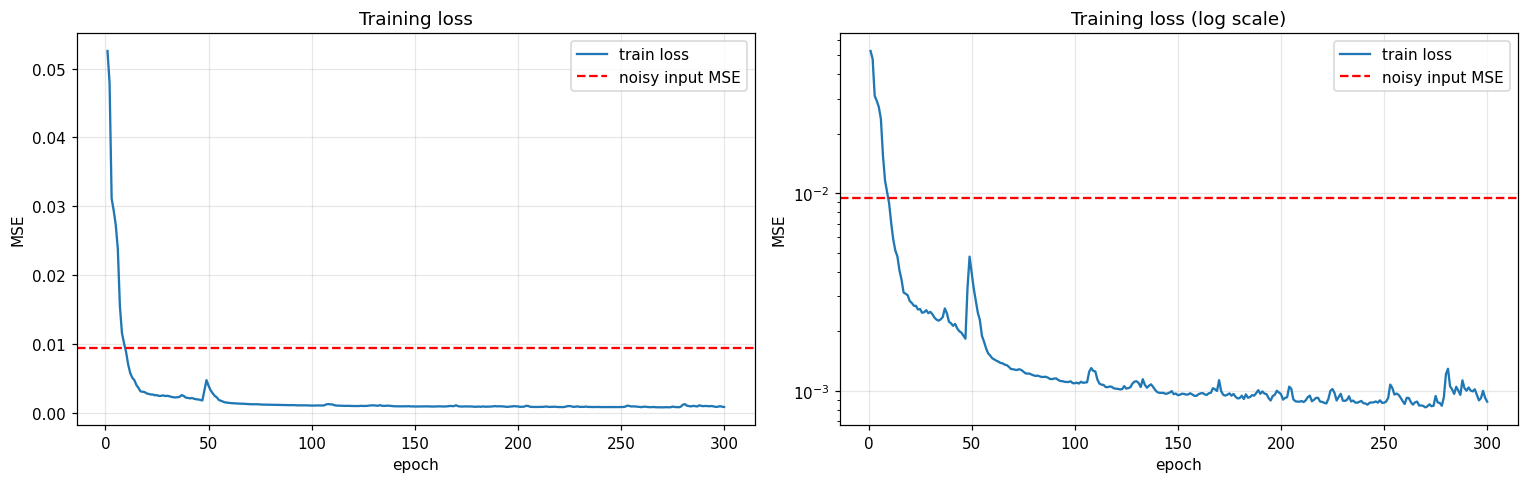

first epoch: 0.052546 | last epoch: 0.000880 | lowest: 0.000823 (epoch 270, not used for model selection)
The training loss had stopped improving: it was 8.5% higher on average over the last 30 epochs than over the 30 before, because of small spikes, so more epochs would not help.


In [35]:
losses = torch.tensor(loss_history)    # losses as a tensor, one value per epoch

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))                          # linear and log plot
for ax, log in zip(axes, [False, True]):                                   # same plot twice
    ax.plot(range(1, EPOCHS + 1), losses.numpy(), label="train loss")      # loss curve
    ax.axhline(train_noisy_mse, color="r", ls="--", label="noisy input MSE")   # "do nothing" level
    ax.set(xlabel="epoch", ylabel="MSE", title="Training loss" + (" (log scale)" if log else ""))   # labels
    if log:                                                                # second panel
        ax.set_yscale("log")                                               # log scale shows late improvements
    ax.grid(alpha=0.3)                                                     # light grid
    ax.legend()                                                            # legend
fig.tight_layout()                                                         # tidy spacing
fig.savefig(f"{OUT_DIR}/loss_curve.png", bbox_inches="tight")              # save
plt.show()                                                                 # display

# compare the average loss of the last 30 epochs with the 30 before that
w = max(5, EPOCHS // 10)                                                                # window size (30 epochs)
recent_drop = 100 * (losses[-2 * w:-w].mean() - losses[-w:].mean()).item() / losses[-2 * w:-w].mean().item()   # % decrease
if recent_drop > 2:                                                                     # still clearly improving
    loss_trend = (f"The training loss was still going down at the end ({recent_drop:.1f}% lower over the last "
                  f"{w} epochs), so more epochs would probably lower the training error further.")
elif recent_drop < -2:                                                                  # slightly higher at the end
    loss_trend = (f"The training loss had stopped improving: it was {abs(recent_drop):.1f}% higher on average over the last "
                  f"{w} epochs than over the {w} before, because of small spikes, so more epochs would not help.")
else:                                                                                   # basically flat
    loss_trend = f"The training loss had roughly flattened out by the end ({recent_drop:.1f}% change over the last {w} epochs)."

print(f"first epoch: {losses[0]:.6f} | last epoch: {losses[-1]:.6f} | "
      f"lowest: {losses.min():.6f} (epoch {losses.argmin().item() + 1}, not used for model selection)")   # key loss values
print(loss_trend)                                                                                         # trend sentence

# Part 7: Model Evaluation
MSE, PSNR and SSIM on the training set and the unseen test set, the results table and reconstruction examples.

## 24. Evaluation functions

- **MSE**: mean squared pixel error per image
- **PSNR** = 10 log10(1 / MSE) in dB, since the maximum pixel value is 1
- **SSIM**: standard SSIM with an 11x11 Gaussian window (sigma 1.5), K1 = 0.01, K2 = 0.03

Metrics are computed per image and then averaged. The same metrics are computed for the noisy input as a baseline.

In [36]:
def mse_per_image(a, b):                               # a, b: (N, 1, H, W)
    return ((a - b) ** 2).mean(dim=(1, 2, 3))          # squared error averaged over each image -> (N,)

def psnr(mse, max_val=1.0):                            # MSE -> PSNR in dB
    return 10 * torch.log10(max_val ** 2 / mse)        # 10x smaller MSE = +10 dB

def gaussian_window(size=11, sigma=1.5):               # weights for the local SSIM statistics
    x = torch.arange(size, dtype=torch.float64) - size // 2   # positions -5..5
    g = torch.exp(-x ** 2 / (2 * sigma ** 2))                  # 1D Gaussian
    g = g / g.sum()                                            # weights sum to 1
    return (g[:, None] * g[None, :])[None, None]               # 2D window, (1, 1, 11, 11) for conv2d

def ssim(a, b, max_val=1.0):                           # a, b: (N, 1, H, W) -> (N,)
    a, b = a.double(), b.double()                      # double precision for stable variances
    w = gaussian_window().to(a.device)                 # window on the same device
    c1, c2 = (0.01 * max_val) ** 2, (0.03 * max_val) ** 2   # small constants to avoid division by zero

    mu_a, mu_b = F.conv2d(a, w), F.conv2d(b, w)          # local means
    var_a = F.conv2d(a * a, w) - mu_a ** 2               # local variance of a
    var_b = F.conv2d(b * b, w) - mu_b ** 2               # local variance of b
    cov = F.conv2d(a * b, w) - mu_a * mu_b               # local covariance

    s = ((2 * mu_a * mu_b + c1) * (2 * cov + c2)) / ((mu_a ** 2 + mu_b ** 2 + c1) * (var_a + var_b + c2))   # SSIM map
    return s.mean(dim=(1, 2, 3)).float()                 # average over the map -> one score per image

@torch.no_grad()                                         # no gradients during evaluation
def evaluate(model, loader):                             # reconstruct a set and compute all metrics
    model.eval()                                         # evaluation mode
    noisy, clean, recon, ids = [], [], [], []            # collect results batch by batch
    for x, y, i in loader:                               # x noisy, y clean, i ids
        recon.append(model(x.to(device)).cpu())          # reconstruct and bring back to CPU
        noisy.append(x); clean.append(y); ids.append(i)  # keep inputs, targets and ids
    res = {"noisy": torch.cat(noisy), "clean": torch.cat(clean),
           "recon": torch.cat(recon), "ids": torch.cat(ids)}     # join the batches
    for name in ["recon", "noisy"]:                      # metrics for the output and for the noisy baseline
        mse = mse_per_image(res[name], res["clean"])     # per-image MSE
        res[f"mse_{name}"] = mse                         # store MSE
        res[f"psnr_{name}"] = psnr(mse)                  # store PSNR
        res[f"ssim_{name}"] = ssim(res[name], res["clean"])   # store SSIM
    return res                                           # everything in one dict

def per_image_table(res):                                # per-image metrics as a DataFrame
    cols = ["mse_noisy", "mse_recon", "psnr_noisy", "psnr_recon", "ssim_noisy", "ssim_recon"]   # columns to show
    df = pd.DataFrame({c: res[c].numpy() for c in cols})     # tensors -> table
    df.insert(0, "cifar_idx", res["ids"].numpy())             # image id as first column
    return df

def summary(res):                                        # mean of each metric over the images
    return {k: res[k].mean().item() for k in
            ["mse_recon", "psnr_recon", "ssim_recon", "mse_noisy", "psnr_noisy", "ssim_noisy"]}

def print_summary(name, res):                            # readable printout of one set
    print(f"{name} ({len(res['ids'])} images)")          # set name and size
    for m, unit, fmt in [("mse", "", ".6f"), ("psnr", " dB", ".2f"), ("ssim", "", ".4f")]:   # each metric
        r, n = res[f"{m}_recon"], res[f"{m}_noisy"]      # reconstruction and noisy values
        print(f"  {m.upper():<4}  recon {r.mean():{fmt}} +/- {r.std():{fmt}}{unit}   noisy input {n.mean():{fmt}}{unit}")   # mean +/- std

## 25. Evaluate on the training set

In [37]:
train_res = evaluate(model, train_eval_loader)   # reconstruct the 80 training images
print_summary("TRAIN", train_res)                # print mean metrics

train_table = per_image_table(train_res)                                 # per-image table
display(train_table.describe().round(5))                                 # count, mean, std, min, quartiles, max
train_table.to_csv(f"{OUT_DIR}/metrics_train_per_image.csv", index=False)   # save

TRAIN (80 images)
  MSE   recon 0.000854 +/- 0.000179   noisy input 0.009409
  PSNR  recon 30.78 +/- 0.94 dB   noisy input 20.27 dB
  SSIM  recon 0.8997 +/- 0.0251   noisy input 0.4522


,cifar_idx,mse_noisy,mse_recon,psnr_noisy,psnr_recon,ssim_noisy,ssim_recon
count,80.00000,80.00000,80.00000,80.00000,80.00000,80.00000,80.00000
mean,26556.81250,0.00941,0.00085,20.27441,30.78099,0.45216,0.89973
std,14802.28741,0.00061,0.00018,0.29894,0.94192,0.10367,0.02514
min,216.00000,0.00709,0.00038,19.89664,28.13012,0.20472,0.83711
25%,13910.75000,0.00903,0.00075,20.08787,30.23529,0.39194,0.88511
50%,27154.00000,0.00962,0.00086,20.16658,30.66761,0.46565,0.90168
75%,39514.25000,0.00980,0.00095,20.44503,31.25324,0.52342,0.91432
max,49417.00000,0.01024,0.00154,21.49239,34.17282,0.65313,0.95313


## 26. Evaluate on the unseen test set

First and only time the test images go through the model.

In [38]:
assert not (seen_ids & set(test_ids.tolist())), "a test image was used in training"   # confirm test isolation first

test_res = evaluate(model, test_loader)   # reconstruct the 20 test images
print_summary("TEST", test_res)           # print mean metrics

test_table = per_image_table(test_res)                                   # per-image table
display(test_table.round(5))                                             # 20 rows, show them all
test_table.to_csv(f"{OUT_DIR}/metrics_test_per_image.csv", index=False)  # save

TEST (20 images)
  MSE   recon 0.000975 +/- 0.000252   noisy input 0.009275
  PSNR  recon 30.24 +/- 1.07 dB   noisy input 20.35 dB
  SSIM  recon 0.8880 +/- 0.0163   noisy input 0.4223


,cifar_idx,mse_noisy,mse_recon,psnr_noisy,psnr_recon,ssim_noisy,ssim_recon
0,44491,0.01022,0.00060,19.906780,32.222618,0.23842,0.86956
1,17004,0.00876,0.00118,20.574881,29.295019,0.44792,0.88900
2,43777,0.01016,0.00079,19.932390,31.018499,0.31144,0.87204
3,39339,0.00989,0.00169,20.047600,27.723120,0.55797,0.87462
4,8205,0.00940,0.00092,20.267639,30.346621,0.39254,0.90065
5,20844,0.00752,0.00118,21.238199,29.266840,0.57037,0.92233
6,21000,0.00991,0.00082,20.040739,30.865870,0.37228,0.88516
7,42186,0.00703,0.00070,21.531170,31.554770,0.37148,0.86843
8,78,0.01005,0.00119,19.979321,29.233101,0.53525,0.90232
9,6899,0.00954,0.00078,20.203091,31.053301,0.35614,0.87705


## 27. Results table

In [39]:
tr, te = summary(train_res), summary(test_res)          # mean metrics for train and test
train_mse, test_mse = tr["mse_recon"], te["mse_recon"]       # MSE
train_psnr, test_psnr = tr["psnr_recon"], te["psnr_recon"]   # PSNR
train_ssim, test_ssim = tr["ssim_recon"], te["ssim_recon"]   # SSIM

results = pd.DataFrame({
    "MSE": [tr["mse_noisy"], train_mse, te["mse_noisy"], test_mse],              # MSE column
    "PSNR (dB)": [tr["psnr_noisy"], train_psnr, te["psnr_noisy"], test_psnr],    # PSNR column
    "SSIM": [tr["ssim_noisy"], train_ssim, te["ssim_noisy"], test_ssim],         # SSIM column
}, index=pd.MultiIndex.from_tuples([("train", "noisy input"), ("train", "DAE output"),
                                    ("test", "noisy input"), ("test", "DAE output")]))   # row labels
display(results.round(6))                     # show the main table
results.to_csv(f"{OUT_DIR}/results.csv")      # save it

gains = pd.DataFrame({
    "MSE reduction (%)": [100 * (1 - train_mse / tr["mse_noisy"]), 100 * (1 - test_mse / te["mse_noisy"])],   # how much error was removed
    "PSNR gain (dB)": [train_psnr - tr["psnr_noisy"], test_psnr - te["psnr_noisy"]],                         # dB improvement
    "SSIM gain": [train_ssim - tr["ssim_noisy"], test_ssim - te["ssim_noisy"]],                              # SSIM improvement
}, index=["train", "test"])
display(gains.round(4))                       # show the improvements

MSE  PSNR (dB)      SSIM
train noisy input  0.009409  20.274414  0.452160
      DAE output   0.000854  30.780985  0.899726
test  noisy input  0.009275  20.348228  0.422305
      DAE output   0.000975  30.236221  0.888049

,MSE reduction (%),PSNR gain (dB),SSIM gain
train,90.9202,10.5066,0.4476
test,89.4830,9.8880,0.4657


## 28. Training reconstructions

8 randomly picked training images (seeded, not hand-picked). Columns: Clean | Noisy | Reconstructed.

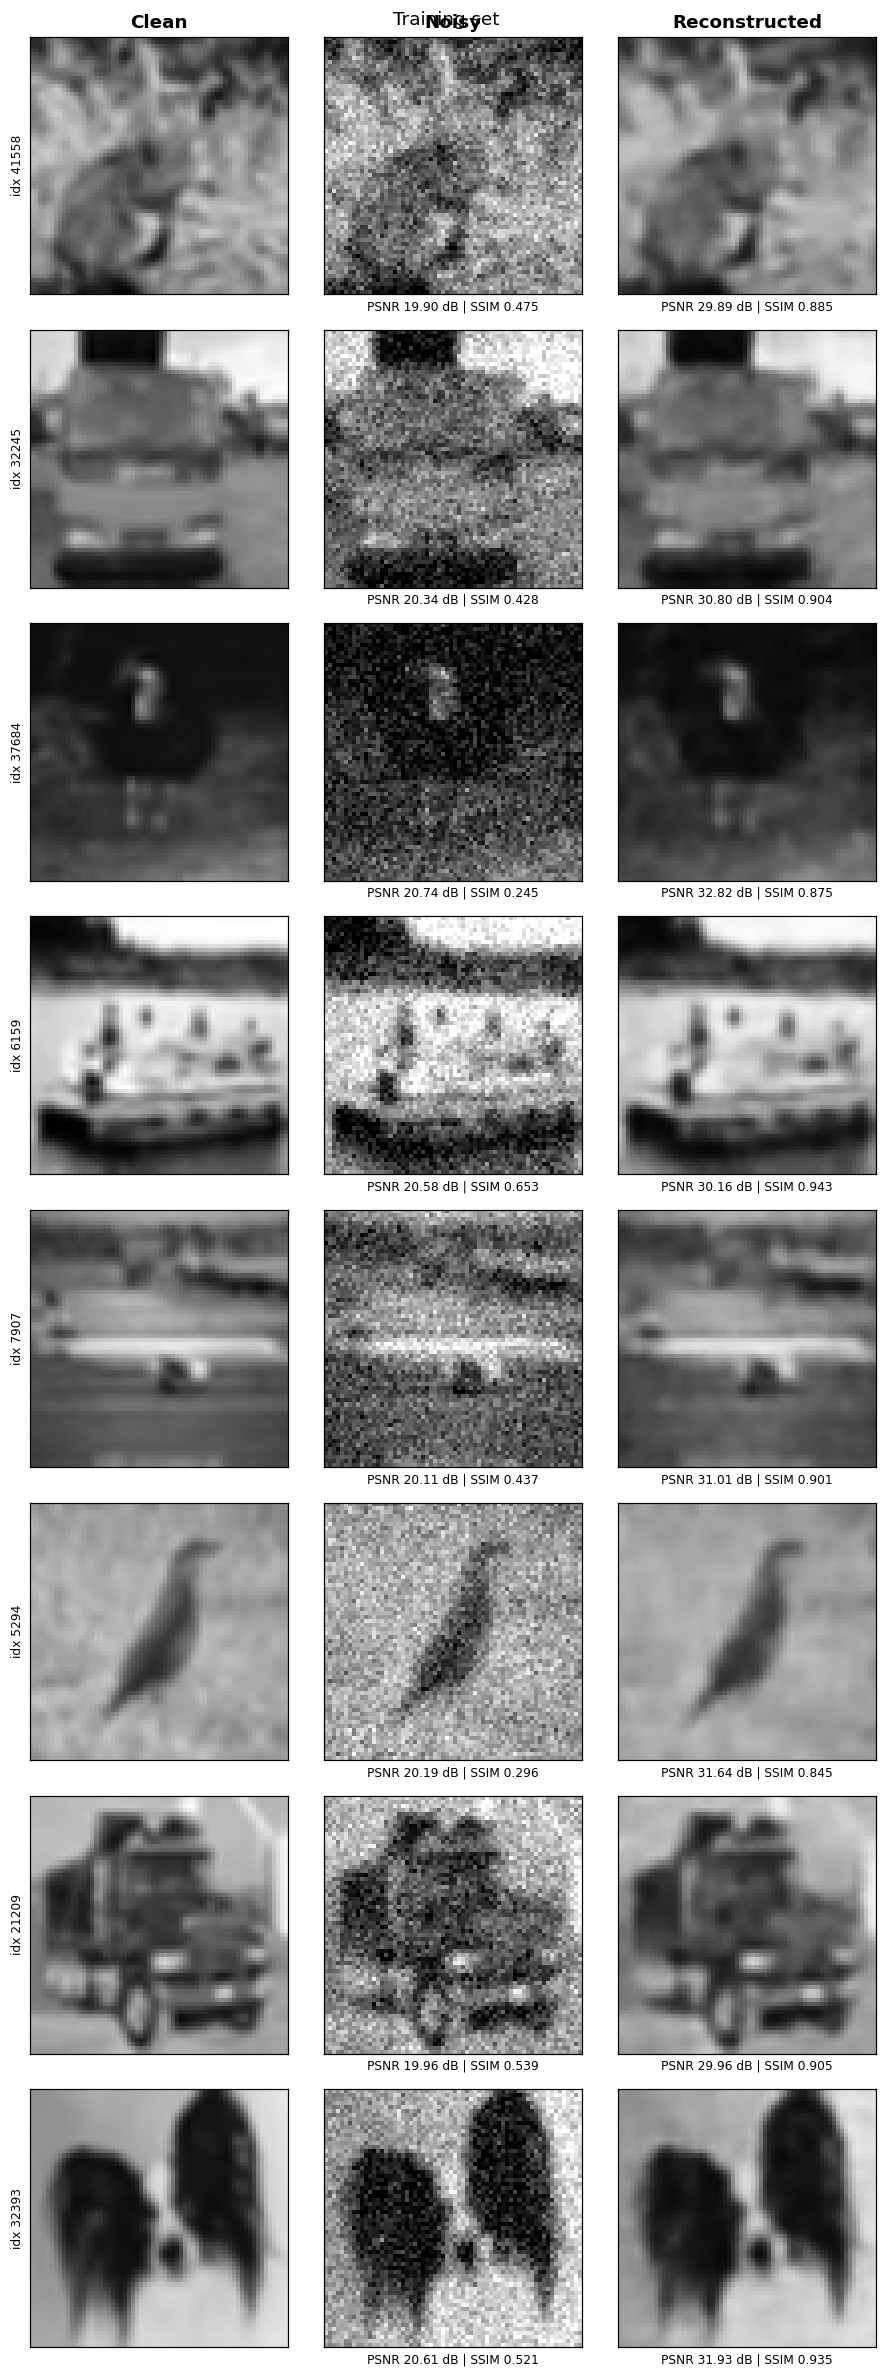

In [40]:
def show_reconstructions(res, rows, title, fname):                                  # Clean | Noisy | Reconstructed grid
    fig, axes = plt.subplots(len(rows), 3, figsize=(8.4, 2.75 * len(rows)), squeeze=False)   # one row per image
    for r, i in enumerate(rows):                                                    # r = row, i = image
        i = int(i)                                                                  # tensor index -> int
        panels = [
            (res["clean"][i], ""),                                                  # clean, no metrics
            (res["noisy"][i], f"PSNR {res['psnr_noisy'][i].item():.2f} dB | SSIM {res['ssim_noisy'][i].item():.3f}"),   # noisy + its metrics
            (res["recon"][i], f"PSNR {res['psnr_recon'][i].item():.2f} dB | SSIM {res['ssim_recon'][i].item():.3f}"),   # output + its metrics
        ]
        for c, (img, text) in enumerate(panels):                                    # the 3 columns
            axes[r, c].imshow(img[0].numpy(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")   # same grey scale everywhere
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])                    # hide ticks
            axes[r, c].set_xlabel(text, fontsize=8)                                 # metrics under the image
        axes[r, 0].set_ylabel(f"idx {res['ids'][i].item()}", fontsize=8)            # CIFAR index
    for c, name in enumerate(["Clean", "Noisy", "Reconstructed"]):                  # column titles
        axes[0, c].set_title(name, fontweight="bold")
    fig.suptitle(title)                                                             # figure title
    fig.tight_layout()                                                              # tidy spacing
    fig.savefig(f"{OUT_DIR}/{fname}", bbox_inches="tight")                          # save
    plt.show()                                                                      # display

rows = torch.randperm(N_TRAIN, generator=torch.Generator().manual_seed(SEED + 20))[:8].sort().values   # 8 random training images
show_reconstructions(train_res, rows, "Training set", "recon_train.png")                              # plot them

## 29. Test reconstructions

8 random test images, then the 3 best and 3 worst test images by MSE.

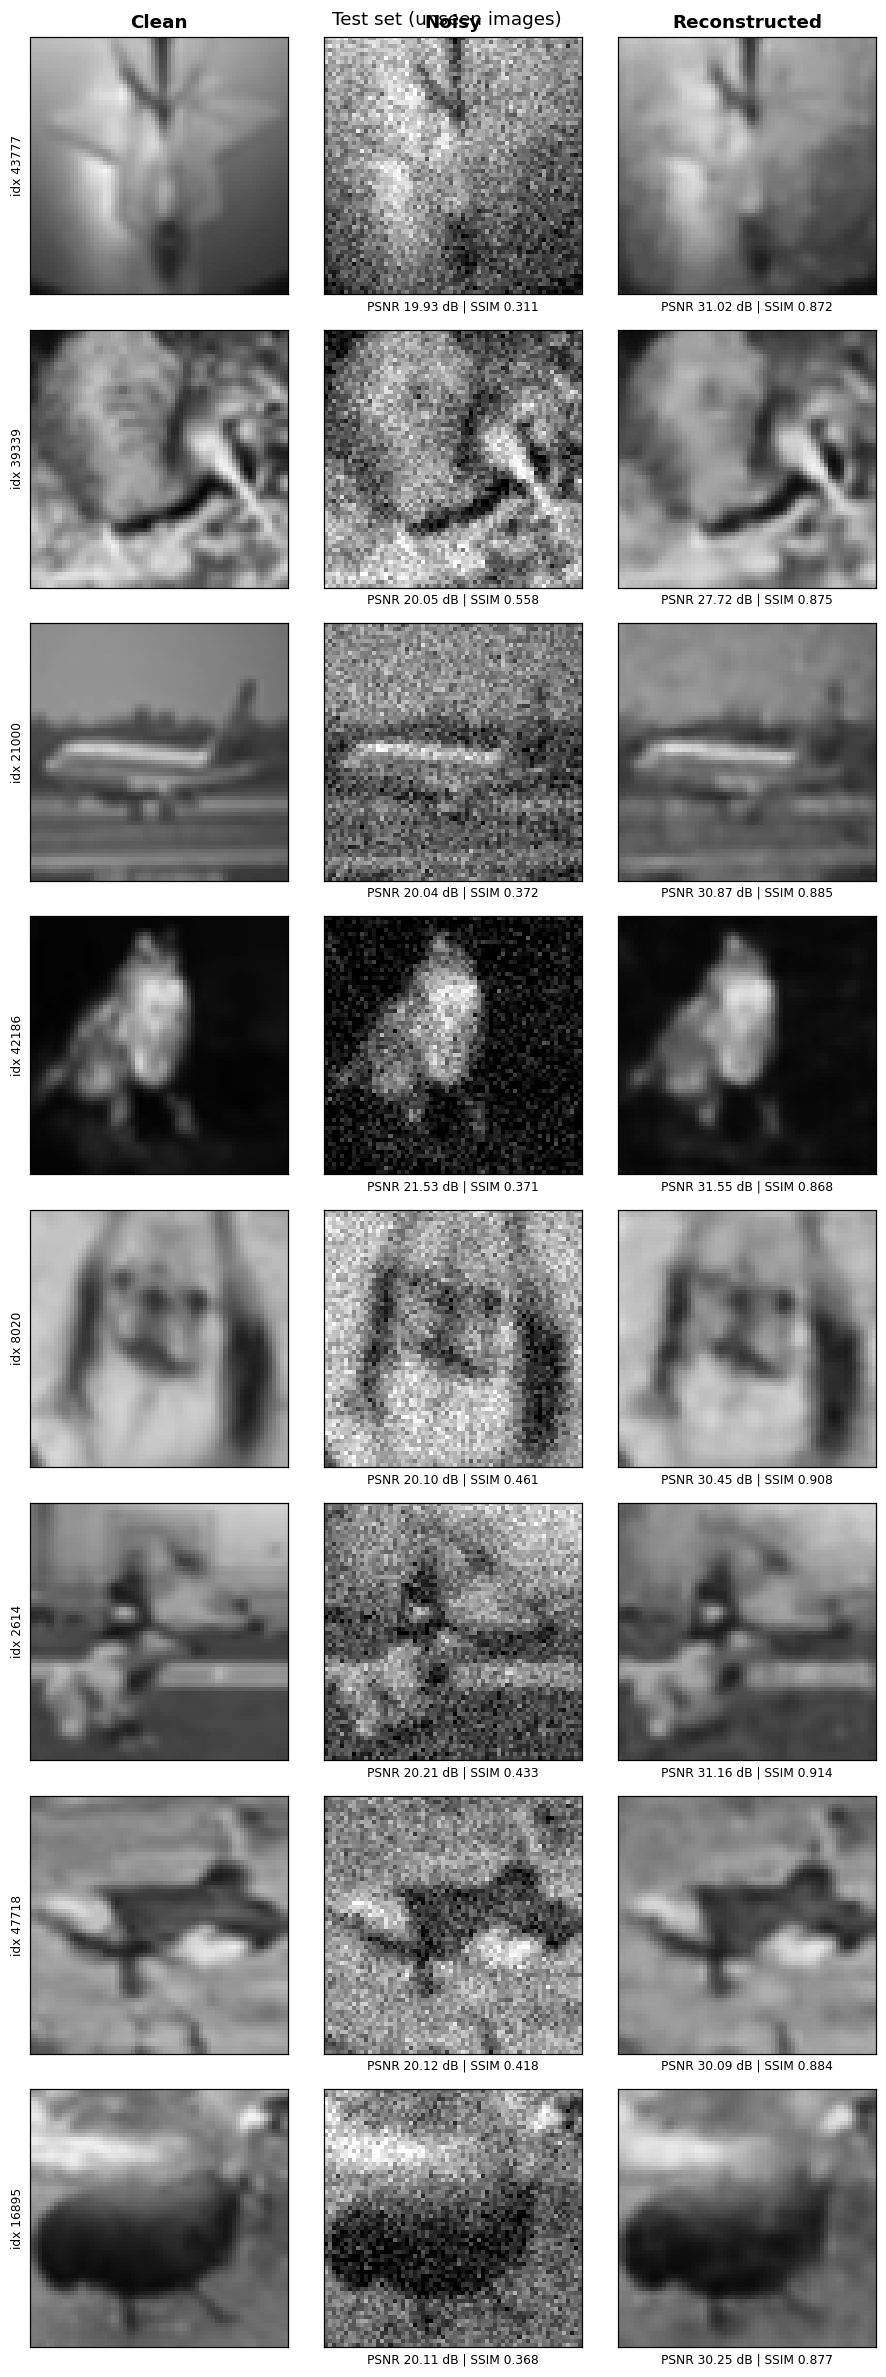

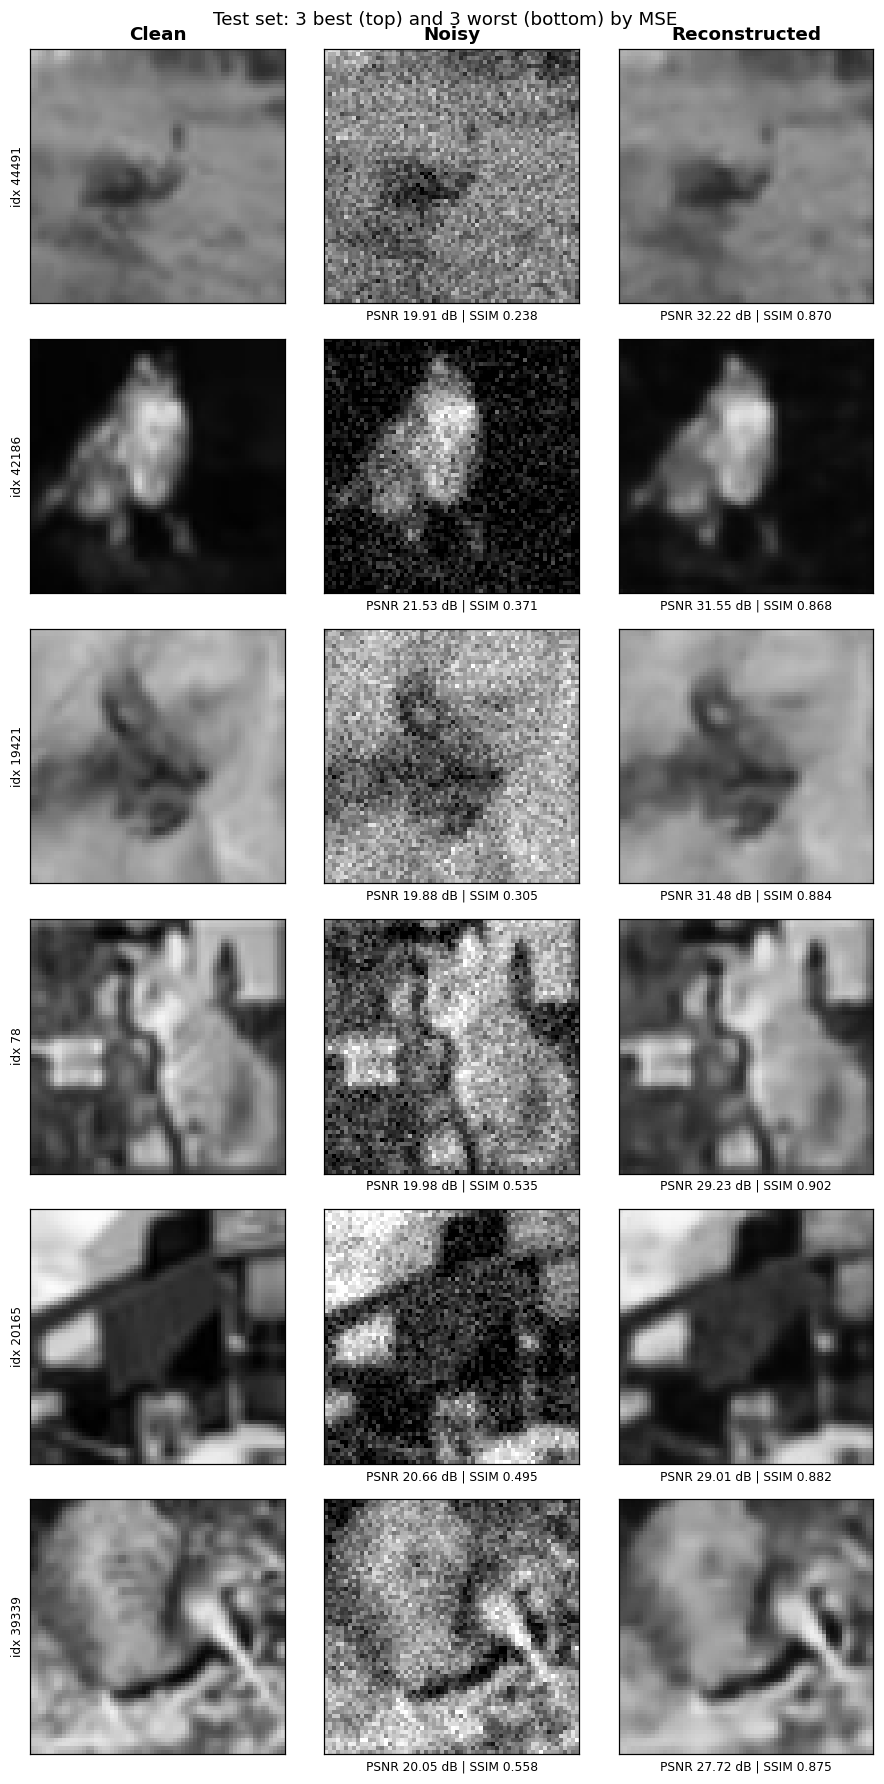

In [41]:
rows = torch.randperm(N_TEST, generator=torch.Generator().manual_seed(SEED + 21))[:8].sort().values   # 8 random test images
show_reconstructions(test_res, rows, "Test set (unseen images)", "recon_test.png")                   # plot them

order = test_res["mse_recon"].argsort()            # test images sorted by MSE, best first
show_reconstructions(test_res, torch.cat([order[:3], order[-3:]]),
                     "Test set: 3 best (top) and 3 worst (bottom) by MSE", "recon_test_best_worst.png")   # best 3 + worst 3

# Part 8: Analysis and Conclusions
Sanity checks, train/test gap analysis, and the final interpretation, summary and checklist.

## 30. Sanity checks

Plus a simple reference: a fixed Gaussian blur (5x5, sigma 1) applied to the noisy images. Its settings are
fixed, not tuned on the test set.

In [42]:
assert seen_ids == set(train_ids.tolist()), "training loop did not see exactly the 80 training images"   # trained on all 80
assert not (seen_ids & set(test_ids.tolist())), "test image leaked into training"                        # and never on test
assert n_updates == EPOCHS * steps_per_epoch                                  # right number of updates
assert all(torch.isfinite(p).all() for p in model.parameters())               # no NaN/inf weights
assert test_res["recon"].shape == test_res["clean"].shape                     # output shape matches
assert test_res["recon"].min() >= 0 and test_res["recon"].max() <= 1          # output range is valid

# metric checks
assert abs(psnr(torch.tensor(0.01)).item() - 20.0) < 1e-4                     # MSE 0.01 -> 20 dB
assert abs(ssim(test_clean[:1], test_clean[:1]).item() - 1.0) < 1e-6          # SSIM(x, x) = 1
assert abs(F.mse_loss(test_res["recon"], test_res["clean"]).item() - test_mse) < 1e-6   # our MSE matches PyTorch's

# reproducibility of the noise and determinism of the model (train images only, test set is not reused)
assert torch.equal(add_noise(train_clean, NOISE_STD, TRAIN_NOISE_SEED)[1], train_noisy)   # same seed -> same train noise
assert torch.equal(add_noise(test_clean, NOISE_STD, TEST_NOISE_SEED)[1], test_noisy)      # same seed -> same test noise
assert torch.allclose(evaluate(model, train_eval_loader)["recon"], train_res["recon"], atol=1e-6)   # same output twice

print("All sanity checks passed.")                               # all asserts passed
print(f"loss went from {losses[0]:.6f} to {losses[-1]:.6f}")     # training reduced the loss

# Gaussian blur baseline
def blur_scores(res):                                                         # metrics of a simple blur filter
    blurred = TF.gaussian_blur(res["noisy"], kernel_size=5, sigma=1.0)        # smooth the noisy images
    m = mse_per_image(blurred, res["clean"])                                  # per-image MSE
    return [m.mean().item(), psnr(m).mean().item(), ssim(blurred, res["clean"]).mean().item()]   # MSE, PSNR, SSIM

baseline = pd.DataFrame(
    [[tr["mse_noisy"], tr["psnr_noisy"], tr["ssim_noisy"]], blur_scores(train_res), [train_mse, train_psnr, train_ssim],   # train rows
     [te["mse_noisy"], te["psnr_noisy"], te["ssim_noisy"]], blur_scores(test_res), [test_mse, test_psnr, test_ssim]],      # test rows
    columns=["MSE", "PSNR (dB)", "SSIM"],                                                      # metric columns
    index=pd.MultiIndex.from_product([["train", "test"], ["noisy input", "gaussian blur", "DAE"]]),   # row labels
)
display(baseline.round(5))                                                    # show the comparison
baseline.to_csv(f"{OUT_DIR}/baseline_comparison.csv")                         # save it
blur_test_mse, blur_test_psnr, blur_test_ssim = baseline.loc[("test", "gaussian blur")]   # blur results on test

frac_mse_better = (test_res["mse_recon"] < test_res["mse_noisy"]).float().mean().item()     # share of test images with lower MSE
frac_ssim_better = (test_res["ssim_recon"] > test_res["ssim_noisy"]).float().mean().item()  # share with higher SSIM
print(f"test images where the DAE lowered MSE: {100 * frac_mse_better:.0f}%, raised SSIM: {100 * frac_ssim_better:.0f}%")

All sanity checks passed.
loss went from 0.052546 to 0.000880


MSE  PSNR (dB)     SSIM
train noisy input    0.00941   20.27441  0.45216
      gaussian blur  0.00131   28.91262  0.84589
      DAE            0.00085   30.78098  0.89973
test  noisy input    0.00928   20.34823  0.42231
      gaussian blur  0.00126   29.09639  0.83730
      DAE            0.00098   30.23622  0.88805

test images where the DAE lowered MSE: 100%, raised SSIM: 100%


## 31. Train/test gap

- MSE difference = test MSE - train MSE
- relative gap = (test MSE - train MSE) / train MSE
- PSNR difference = train PSNR - test PSNR, SSIM difference = train SSIM - test SSIM

Bootstrap intervals (resampling images with replacement) show how much these numbers could move with a
different set of images. With 20 test images the intervals are wide.

train MSE          0.000854
test MSE           0.000975  (95% CI 0.000874 - 0.001089)
MSE difference     +0.000121
relative gap       +14.18%  (95% CI +1.4% to +28.7%)
PSNR difference    +0.545 dB
SSIM difference    +0.0117
error left after denoising: train 0.091, test 0.105 (fraction of noisy-input MSE)
rank correlation edge strength vs MSE: +0.797


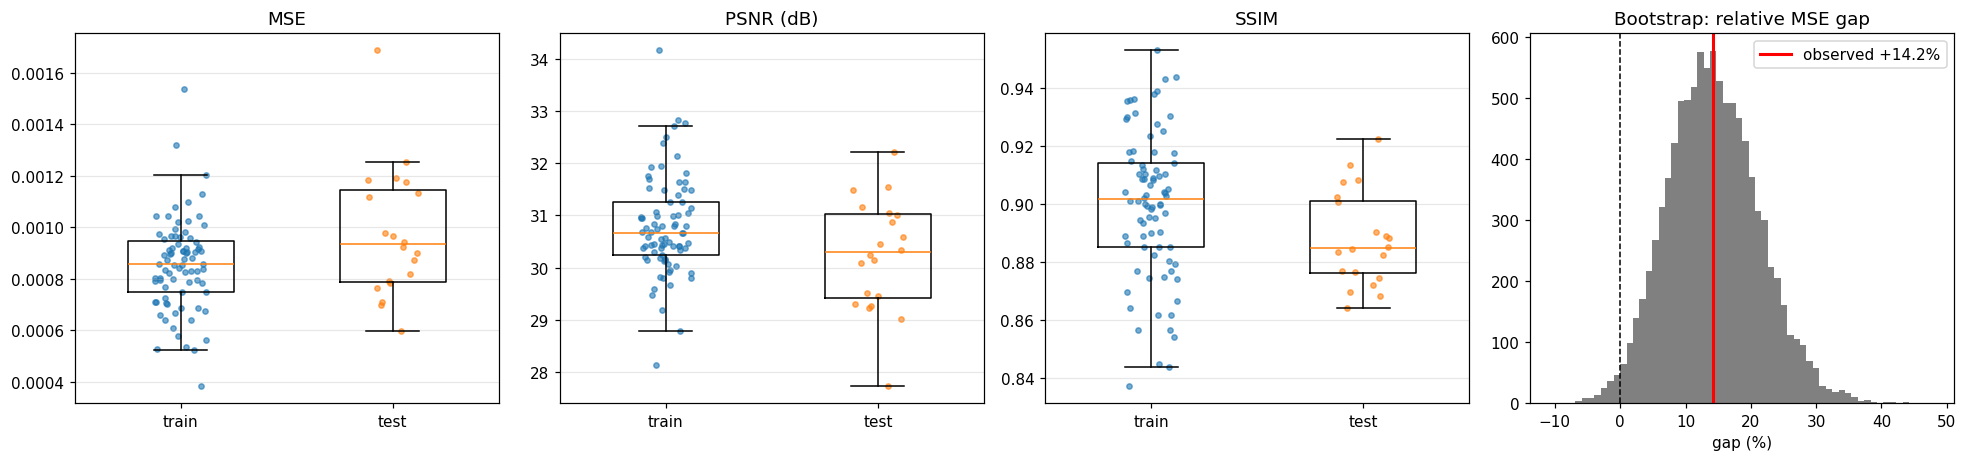

In [43]:
mse_diff = test_mse - train_mse          # positive = worse on test
rel_gap = 100 * mse_diff / train_mse     # same thing as a % of the train MSE
psnr_diff = train_psnr - test_psnr       # positive = lower PSNR on test
ssim_diff = train_ssim - test_ssim       # positive = lower SSIM on test

def bootstrap_means(values, n=10000, seed=SEED + 30):                    # means of n resampled versions of `values`
    g = torch.Generator().manual_seed(seed)                              # seeded for reproducibility
    idx = torch.randint(len(values), (n, len(values)), generator=g)      # random indices with replacement, (n, len)
    return values.double()[idx].mean(dim=1)                             # mean of each resample, (n,)

def ci95(samples):                                                       # 95% interval from bootstrap samples
    return torch.quantile(samples, torch.tensor([0.025, 0.975], dtype=samples.dtype)).tolist()   # 2.5% and 97.5% points

boot_train = bootstrap_means(train_res["mse_recon"], seed=SEED + 30)     # resampled train MSE means
boot_test = bootstrap_means(test_res["mse_recon"], seed=SEED + 31)       # resampled test MSE means
boot_gap = 100 * (boot_test - boot_train) / boot_train                   # resampled relative gaps

gap_ci = ci95(boot_gap)                                                          # interval for the relative gap
test_mse_ci = ci95(boot_test)                                                    # interval for test MSE
test_psnr_ci = ci95(bootstrap_means(test_res["psnr_recon"], seed=SEED + 32))     # interval for test PSNR
test_ssim_ci = ci95(bootstrap_means(test_res["ssim_recon"], seed=SEED + 33))     # interval for test SSIM

# how much of the noisy-input error is left after denoising, for each set
train_left = train_mse / tr["mse_noisy"]     # fraction of error left on train
test_left = test_mse / te["mse_noisy"]       # fraction of error left on test

# do more detailed images get reconstructed worse? (rank correlation over all 100 images)
edges = torch.cat([edge_strength(train_res["clean"]), edge_strength(test_res["clean"])])   # detail of each clean image
errs = torch.cat([train_res["mse_recon"], test_res["mse_recon"]])                          # reconstruction error of each image
rank = lambda v: v.argsort().argsort().double()                                            # values -> ranks
edge_corr = torch.corrcoef(torch.stack([rank(edges), rank(errs)]))[0, 1].item()            # Spearman correlation

print(f"train MSE          {train_mse:.6f}")                                                          # train MSE
print(f"test MSE           {test_mse:.6f}  (95% CI {test_mse_ci[0]:.6f} - {test_mse_ci[1]:.6f})")     # test MSE + interval
print(f"MSE difference     {mse_diff:+.6f}")                                                          # test - train
print(f"relative gap       {rel_gap:+.2f}%  (95% CI {gap_ci[0]:+.1f}% to {gap_ci[1]:+.1f}%)")         # relative gap + interval
print(f"PSNR difference    {psnr_diff:+.3f} dB")                                                      # train - test PSNR
print(f"SSIM difference    {ssim_diff:+.4f}")                                                         # train - test SSIM
print(f"error left after denoising: train {train_left:.3f}, test {test_left:.3f} (fraction of noisy-input MSE)")
print(f"rank correlation edge strength vs MSE: {edge_corr:+.3f}")                                     # detail vs error

pd.Series({"train_mse": train_mse, "test_mse": test_mse, "mse_diff": mse_diff, "rel_gap_pct": rel_gap,
           "rel_gap_ci_low": gap_ci[0], "rel_gap_ci_high": gap_ci[1], "psnr_diff": psnr_diff,
           "ssim_diff": ssim_diff}).to_csv(f"{OUT_DIR}/gap_analysis.csv")                             # save the gap numbers

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))                         # 3 metric plots + bootstrap histogram
jitter = torch.Generator().manual_seed(SEED + 34)                         # seeded jitter for the dots
for ax, (key, name) in zip(axes, [("mse_recon", "MSE"), ("psnr_recon", "PSNR (dB)"), ("ssim_recon", "SSIM")]):   # one panel per metric
    data = [train_res[key].numpy(), test_res[key].numpy()]               # per-image values for train and test
    ax.boxplot(data, widths=0.5, showfliers=False)                       # boxes
    for k, d in enumerate(data, start=1):                                # dots for each image
        x = k + (torch.rand(len(d), generator=jitter).numpy() - 0.5) * 0.25   # small sideways jitter
        ax.scatter(x, d, s=12, alpha=0.6)                                # one dot per image
    ax.set_xticks([1, 2])                                                # two groups
    ax.set_xticklabels(["train", "test"])                                # group names
    ax.set_title(name)                                                   # metric name
    ax.grid(alpha=0.3, axis="y")                                         # light grid
axes[3].hist(boot_gap.numpy(), bins=60, color="gray")                    # bootstrap distribution of the gap
axes[3].axvline(rel_gap, color="r", lw=2, label=f"observed {rel_gap:+.1f}%")   # observed gap
axes[3].axvline(0, color="k", ls="--", lw=1)                             # zero gap reference
axes[3].set(title="Bootstrap: relative MSE gap", xlabel="gap (%)")       # labels
axes[3].legend()                                                         # legend
fig.tight_layout()                                                       # tidy spacing
fig.savefig(f"{OUT_DIR}/gap_analysis.png", bbox_inches="tight")          # save
plt.show()                                                               # display

## 32. Interpretation, summary and checklist

Everything printed below is built from the numbers of this run.

In [44]:
def report(title, text):                         # print a titled, wrapped section
    print("\n" + title)                          # section title
    print("-" * len(title))                      # underline
    for line in text.strip().split("\n"):        # each paragraph
        print(textwrap.fill(line, 100))          # wrapped at 100 characters

# --- qualitative indicators ---
edge_ratio = (edge_strength(test_res["recon"]).mean() / edge_strength(test_res["clean"]).mean()).item()        # detail in output vs clean
edge_ratio_noisy = (edge_strength(test_res["noisy"]).mean() / edge_strength(test_res["clean"]).mean()).item()  # detail in noisy vs clean

if edge_ratio < 0.85:                            # output has clearly less detail -> blurry
    sharpness = (f"The reconstructions are smoother than the clean images (edge ratio {edge_ratio:.2f}): noise is "
                 f"removed but some fine detail is lost too, which is typical for an MSE-trained autoencoder.")
elif edge_ratio <= 1.15:                         # about the same amount of detail
    sharpness = (f"The reconstructions have about the same amount of edges as the clean images (ratio {edge_ratio:.2f}, "
                 f"vs {edge_ratio_noisy:.2f} for the noisy input), so on average noise was removed without heavy blurring.")
else:                                            # more detail than clean -> leftover noise
    sharpness = (f"The reconstructions still have more high-frequency content than the clean images (ratio "
                 f"{edge_ratio:.2f}, vs {edge_ratio_noisy:.2f} for the noisy input), i.e. some noise or artefacts remain.")

if edge_corr > 0.3:                              # detailed images -> higher error
    detail = f"Images with more texture tended to be reconstructed worse (rank correlation {edge_corr:.2f})."
elif edge_corr < -0.3:                           # detailed images -> lower error
    detail = f"Images with more texture tended to have lower error (rank correlation {edge_corr:.2f})."
else:                                            # no clear link
    detail = f"There was no clear link between how detailed an image is and its error (rank correlation {edge_corr:.2f})."

if test_mse < blur_test_mse:                     # DAE beats the blur
    vs_blur = (f"On the test set the DAE (MSE {test_mse:.6f}) did better than a plain Gaussian blur "
               f"(MSE {blur_test_mse:.6f}, PSNR {blur_test_psnr:.2f} dB, SSIM {blur_test_ssim:.4f}).")
else:                                            # blur is as good or better
    vs_blur = (f"On the test set the DAE (MSE {test_mse:.6f}) did not beat a plain Gaussian blur "
               f"(MSE {blur_test_mse:.6f}), so the learned model adds little over simple smoothing in this run.")

best_idx = test_res["ids"][order[0]].item()      # CIFAR index of the best test image
worst_idx = test_res["ids"][order[-1]].item()    # CIFAR index of the worst test image

# --- generalization ---
gap_includes_zero = gap_ci[0] <= 0 <= gap_ci[1]  # is "no gap" inside the interval?
if rel_gap < 0:                                  # test better than train
    gap_label = "negative"
    gap_text = (f"The test MSE is {abs(rel_gap):.1f}% lower than the training MSE. With 20 test images this is most "
                f"likely down to which images ended up in the test set, not better performance on new data.")
elif rel_gap <= 10:                              # small gap
    gap_label = "small"
    gap_text = f"The gap between train and test MSE is small ({rel_gap:.1f}%), so there is no strong sign of overfitting in this run."
elif rel_gap <= 25:                              # moderate gap
    gap_label = "moderate"
    gap_text = (f"The test MSE is {rel_gap:.1f}% higher than the training MSE, a moderate gap that suggests some "
                f"overfitting to the 80 training images.")
else:                                            # large gap
    gap_label = "large"
    gap_text = (f"The test MSE is {rel_gap:.1f}% higher than the training MSE. That is a large gap and points to "
                f"overfitting: with {n_params:,} parameters for 80 images the model can partly memorise the training set.")

gap_text += (f" The bootstrap 95% interval for the gap is {gap_ci[0]:+.1f}% to {gap_ci[1]:+.1f}%"
             + (", which includes zero, so the gap could be due to chance." if gap_includes_zero
                else ", which does not include zero."))                  # add the uncertainty
if test_mse < te["mse_noisy"]:                   # model still helps on unseen images
    gap_text += (f" On unseen images the model still cut the error by {100 * (1 - test_left):.1f}% compared to the "
                 f"noisy input ({test_psnr - te['psnr_noisy']:+.2f} dB PSNR), so what it learned does transfer to some degree.")
else:                                            # model doesn't help on unseen images
    gap_text += " On unseen images the model did not improve on the noisy input, so it did not generalize in a useful way."
gap_text += " " + loss_trend                     # add the loss-curve observation

report("1-10. Results", f"""
1. Train MSE:  {train_mse:.6f}
2. Test MSE:   {test_mse:.6f}  (95% CI {test_mse_ci[0]:.6f} - {test_mse_ci[1]:.6f})
3. Train PSNR: {train_psnr:.2f} dB
4. Test PSNR:  {test_psnr:.2f} dB  (95% CI {test_psnr_ci[0]:.2f} - {test_psnr_ci[1]:.2f})
5. Train SSIM: {train_ssim:.4f}
6. Test SSIM:  {test_ssim:.4f}  (95% CI {test_ssim_ci[0]:.4f} - {test_ssim_ci[1]:.4f})
7. MSE difference (test - train): {mse_diff:+.6f}
8. Relative gap: {rel_gap:+.2f}% ({gap_label})
9. PSNR difference (train - test): {psnr_diff:+.3f} dB
10. SSIM difference (train - test): {ssim_diff:+.4f}
Noisy input for reference: train MSE {tr['mse_noisy']:.6f} / {tr['psnr_noisy']:.2f} dB / SSIM {tr['ssim_noisy']:.4f}, test MSE {te['mse_noisy']:.6f} / {te['psnr_noisy']:.2f} dB / SSIM {te['ssim_noisy']:.4f}
""")   # the 10 required numbers

report("11. Qualitative analysis", f"""
On the test set the DAE lowered the MSE for {100 * frac_mse_better:.0f}% of the images and raised SSIM for {100 * frac_ssim_better:.0f}% of them (average PSNR change {test_psnr - te['psnr_noisy']:+.2f} dB, SSIM change {test_ssim - te['ssim_noisy']:+.4f}).
{sharpness}
{detail}
Best test image: CIFAR idx {best_idx} (MSE {test_res['mse_recon'].min():.6f}); worst: CIFAR idx {worst_idx} (MSE {test_res['mse_recon'].max():.6f}).
{vs_blur}
The numbers should be read together with the reconstruction figures: MSE and PSNR reward pixel accuracy and can favour blurry outputs, while SSIM is more sensitive to structure.
""")   # what the reconstructions look like

report("12. Overfitting / generalization", f"""
{gap_text}
A low training error on its own does not show that the model generalizes; only the 20 held-out images say anything about unseen data, and 20 images are too few to establish strong generalization.
""")   # overfitting discussion

report("13. Dataset limitations", f"""
- Very small dataset: {N_IMAGES} images, {N_TRAIN} for training and only {N_TEST} for testing.
- The random selection is not class-balanced: between {class_counts['selected 100'].min()} and {class_counts['selected 100'].max()} images per class ID, and the test set covers {classes_in_test} of {n_classes} classes.
- The test metrics are uncertain: the 95% interval for test MSE spans {100 * (test_mse_ci[1] - test_mse_ci[0]) / test_mse:.0f}% of its mean.
- A different image selection, split, noise sample or seed could give noticeably different numbers; only seed {SEED} was run.
- The images were upsampled from 32x32, so they have no real 64x64 detail and are smoother than native 64x64 photos, which probably makes denoising easier.
- Grayscale only, one noise level (sigma = {NOISE_STD}) of synthetic i.i.d. Gaussian noise, which is simpler than real camera noise.
- One fixed noise sample per image and no validation set; hyperparameters were set in advance rather than tuned.
""")   # limitations

report("14. Summary", f"""
A convolutional denoising autoencoder ({n_params:,} parameters, {latent_shape[0]}x{latent_shape[1]}x{latent_shape[2]} latent code) was trained for {EPOCHS} epochs with Adam (lr {LR}, batch size {BATCH_SIZE}) and MSE loss to recover clean images from inputs corrupted with Gaussian noise (sigma = {NOISE_STD}). The data were {N_IMAGES} randomly chosen CIFAR-10 images (labels not used for selection or training), converted to grayscale, resized to 64x64 and scaled to [0, 1], split {N_TRAIN}/{N_TEST} with seed {SEED}.
On the training images the model reached MSE {train_mse:.6f}, PSNR {train_psnr:.2f} dB and SSIM {train_ssim:.4f}. On the {N_TEST} unseen test images it reached MSE {test_mse:.6f}, PSNR {test_psnr:.2f} dB and SSIM {test_ssim:.4f}, compared with MSE {te['mse_noisy']:.6f}, PSNR {te['psnr_noisy']:.2f} dB and SSIM {te['ssim_noisy']:.4f} for the noisy input. The relative train-test MSE gap was {rel_gap:+.1f}% (95% CI {gap_ci[0]:+.1f}% to {gap_ci[1]:+.1f}%), with PSNR and SSIM differences of {psnr_diff:+.2f} dB and {ssim_diff:+.4f}.
Because the test set has only 20 images and a single seed was used, these results are indicative rather than conclusive.
""")   # report-ready paragraph

checklist = [   # (requirement, satisfied?) pairs, checked from this run's variables and files
    ("CIFAR-10 downloaded with torchvision", len(all_images) == 50000),
    ("100 unique images selected at random, no labels used for selection/training", len(torch.unique(selected_idx)) == N_IMAGES),
    ("Class-ID distribution described in the EDA (no class names)", os.path.exists(f"{OUT_DIR}/class_distribution.csv")),
    ("Grayscale, 64x64, values in [0, 1]", images.shape == (N_IMAGES, 1, 64, 64) and images.max().item() <= 1),
    ("80/20 split with no overlap", len(train_pos) == 80 and len(test_pos) == 20 and not set(train_ids.tolist()) & set(test_ids.tolist())),
    ("Data checks and EDA done", os.path.exists(f"{OUT_DIR}/eda_stats.csv")),
    ("Reproducible Gaussian noise added and analysed", os.path.exists(f"{OUT_DIR}/noise_stats.csv")),
    ("DAE trained with noisy input and clean target (MSE)", n_updates == EPOCHS * steps_per_epoch),
    ("Test images never used for training or model choices", not seen_ids & set(test_ids.tolist())),
    ("MSE, PSNR, SSIM for train and test", all(math.isfinite(v) for v in [train_mse, test_mse, train_psnr, test_psnr, train_ssim, test_ssim])),
    ("Clean | Noisy | Reconstructed figures for train and test",
     all(os.path.exists(f"{OUT_DIR}/{f}") for f in ["recon_train.png", "recon_test.png", "recon_test_best_worst.png"])),
    ("Loss curve plotted", os.path.exists(f"{OUT_DIR}/loss_curve.png")),
    ("Train/test gap analysis", os.path.exists(f"{OUT_DIR}/gap_analysis.png")),
    ("Seeds fixed, reproducibility checked", True),   # the asserts in sections 7, 11 and 30 would have stopped the notebook otherwise
]

print("\n15. Requirement checklist")                     # checklist title
print("-" * 25)                                          # underline
for item, ok in checklist:                               # each requirement
    print(f"[{'x' if ok else ' '}] {item}")              # [x] = done, [ ] = not done
print(f"\n{sum(ok for _, ok in checklist)}/{len(checklist)} done. Files saved in '{OUT_DIR}/':")   # how many are done
for f in sorted(os.listdir(OUT_DIR)):                    # list every saved file
    print("  ", f)



1-10. Results
-------------
1. Train MSE:  0.000854
2. Test MSE:   0.000975  (95% CI 0.000874 - 0.001089)
3. Train PSNR: 30.78 dB
4. Test PSNR:  30.24 dB  (95% CI 29.78 - 30.68)
5. Train SSIM: 0.8997
6. Test SSIM:  0.8880  (95% CI 0.8811 - 0.8952)
7. MSE difference (test - train): +0.000121
8. Relative gap: +14.18% (moderate)
9. PSNR difference (train - test): +0.545 dB
10. SSIM difference (train - test): +0.0117
Noisy input for reference: train MSE 0.009409 / 20.27 dB / SSIM 0.4522, test MSE 0.009275 / 20.35 dB
/ SSIM 0.4223

11. Qualitative analysis
------------------------
On the test set the DAE lowered the MSE for 100% of the images and raised SSIM for 100% of them
(average PSNR change +9.89 dB, SSIM change +0.4657).
The reconstructions have about the same amount of edges as the clean images (ratio 0.92, vs 4.30 for
the noisy input), so on average noise was removed without heavy blurring.
Images with more texture tended to be reconstructed worse (rank correlation 0.80).
Best test

# Task 2: Encoding Image Ordering

**Setup.** Two networks talk to each other:
- **Sender S** sees two images in a particular order `(A, B)` and sends a single bit `m ∈ {0, 1}`.
- **Receiver R** sees the same two images, either in the same order `(A, B)` or swapped `(B, A)`, plus the bit `m`.
  It predicts whether its order **matches** the sender's order (target 1) or not (target 0).

**Why the receiver needs the message.** Every ordered pair is shown to the sender in *both* orders, and the receiver
gets the same order or the swapped order equally often. So from the images alone the receiver can never tell which
order the sender saw: the two possible answers are equally likely (50% accuracy at best). Anything above 50% must come
from information that the sender put into the bit.

**Why one bit is enough.** There are only two possible orders of a pair, (A, B) and (B, A). Choosing between
2 possibilities needs log2(2) = 1 bit.

**How the bit is trained (noisy sigmoid / DRU).** A hard 0/1 decision has zero gradient, so the sender could not
learn if we simply rounded its output during training. A plain sigmoid output (a number between 0 and 1) is
differentiable, but then the "bit" is really a real number: the sender could hide extra information in values like
0.37 vs 0.41, and that information would disappear when we threshold at 0.5 for evaluation.

We use the **discretise/regularise unit (DRU)** of Foerster et al. (2016, "Learning to Communicate with Deep
Multi-Agent Reinforcement Learning"):
- **training:** `message = sigmoid(logit + noise)`, with Gaussian noise `noise ~ N(0, σ²)`. The message is smooth, so
  gradients flow from the receiver back into the sender. The noise destroys small differences such as 0.37 vs 0.41,
  so the only reliable way for the sender to communicate is to push its logit far below or far above 0, which
  makes the message effectively binary;
- **evaluation:** `message = 1 if sigmoid(logit) > 0.5 else 0`, a true one-bit message.

*Why not a straight-through estimator (hard bit forward, sigmoid gradient backward)?* We tried it first. It is
fragile here: if early in training the sender happens to send the same bit for every pair, the receiver learns to
ignore the bit, the sender receives almost no learning signal, and training gets stuck at 50% accuracy. The smooth,
noisy DRU message avoids this dead end.

**Data.** The same 100 randomly selected CIFAR-10 images as Task 1 (same seed), kept in the original RGB 32x32 format.
No labels are used. Images are split 80/20 **by image**, so the held-out pairs are built only from 20 images that
the networks never saw during training.

## T2-1. Imports and random seeds

Task 2 is self-contained: it re-imports what it needs, so it can also be run after restarting the runtime.

In [1]:
import os                                  # creating the outputs folder
import math                                # math.ceil for the number of batches
import random                              # Python's random generator (seeded below)
import time                                # measure training time
import textwrap                            # wrap long lines in the final analysis
import numpy as np                         # only used to seed NumPy's generator
import pandas as pd                        # result tables
import matplotlib.pyplot as plt            # plots
import torch                               # tensors and automatic differentiation
import torch.nn as nn                      # neural-network layers
import torch.nn.functional as F            # functional ops such as binary_cross_entropy_with_logits
import torchvision                         # CIFAR-10 dataset
from torchvision.utils import make_grid    # arrange many images into one grid image

T2_SEED = 42
# Seed for Task 2. Using the same value as Task 1 means the same 100 CIFAR-10 images are selected.

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# Needed for deterministic matrix multiplications on GPU (harmless on CPU).

def seed_all(seed):
    # Seeds every random number generator that the code below uses.
    random.seed(seed)                      # Python's built-in generator
    np.random.seed(seed)                   # NumPy's global generator
    torch.manual_seed(seed)                # PyTorch CPU generator (weight initialisation, randperm, ...)
    torch.cuda.manual_seed_all(seed)       # PyTorch GPU generators (does nothing without a GPU)

seed_all(T2_SEED)                                          # apply the seed now
torch.backends.cudnn.deterministic = True                  # cuDNN must use deterministic convolution algorithms
torch.backends.cudnn.benchmark = False                     # do not let cuDNN pick (possibly different) algorithms per run
torch.use_deterministic_algorithms(True, warn_only=True)   # prefer deterministic ops; only warn if one has no deterministic version

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Uses the GPU when Colab provides one, otherwise the CPU. Models and tensors are moved to this device.

OUT_DIR = "outputs"                        # same output folder as Task 1
os.makedirs(OUT_DIR, exist_ok=True)        # create it if it does not exist yet

T2_N_IMAGES = 100        # exactly 100 CIFAR-10 images
T2_N_TRAIN = 80          # images used to build training pairs
T2_EPOCHS = 40           # passes over all training pairs (fixed in advance, no early stopping)
T2_BATCH = 256           # pair examples per mini-batch
T2_LR = 1e-3             # Adam learning rate
T2_FEAT = 64             # size of the feature vector produced by each pair encoder
T2_NOISE = 1.0           # std of the Gaussian noise added to the message logit during training (DRU, see T2-7)

print("Task 2 seed:", T2_SEED, "| device:", device)   # document the seed and the device

Task 2 seed: 42 | device: cuda


## T2-2. CIFAR-10 download

In [2]:
cifar_t2 = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
# Loads the 50,000 CIFAR-10 training images (downloads them only if they are not in ./data yet).
# Only cifar_t2.data (pixels) is used. cifar_t2.targets (labels) is never accessed in Task 2.

all_rgb = torch.from_numpy(cifar_t2.data).permute(0, 3, 1, 2)
# cifar_t2.data is a NumPy uint8 array of shape (50000, 32, 32, 3) = (images, height, width, RGB).
# permute(0, 3, 1, 2) reorders it to PyTorch's channel-first layout: (50000, 3, 32, 32).

print("all CIFAR-10 training images:", tuple(all_rgb.shape), all_rgb.dtype)   # (50000, 3, 32, 32) uint8

100%|██████████| 170M/170M [00:10<00:00, 16.1MB/s]


all CIFAR-10 training images: (50000, 3, 32, 32) torch.uint8


## T2-3. Random selection of exactly 100 images

A seeded random permutation of all 50,000 indices, first 100 kept: uniform random selection, no labels, no class
restriction. Images stay RGB 32x32. The images are then split 80/20 by image.

selected CIFAR-10 indices: [37542, 44491, 216, 43688, 41558, 32245, 27206, 10863, 2190, 31849, 25408, 33504, 27102, 21934, 40181, 47682, 45747, 17004, 43777, 7433, 45129, 37684, 14817, 38215, 30883, 19763, 14041, 46578, 19871, 39339, 39292, 8205, 47307, 15337, 45371, 20844, 26455, 25747, 21000, 49417, 42186, 49238, 25283, 78, 6899, 15568, 11143, 35952, 37965, 33436, 30770, 9583, 35210, 4856, 8020, 44859, 4191, 19421, 34688, 29312, 20326, 17740, 4894, 20621, 2614, 46726, 19045, 5668, 6159, 47718, 7907, 5294, 42872, 24855, 20370, 21209, 32223, 43179, 44262, 38506, 40214, 16895, 12328, 45173, 46138, 13520, 30459, 20165, 11227, 43731, 42697, 17911, 6857, 33366, 32393, 2860, 19849, 43759, 3139, 6468]
train images: 80 | held-out images: 20


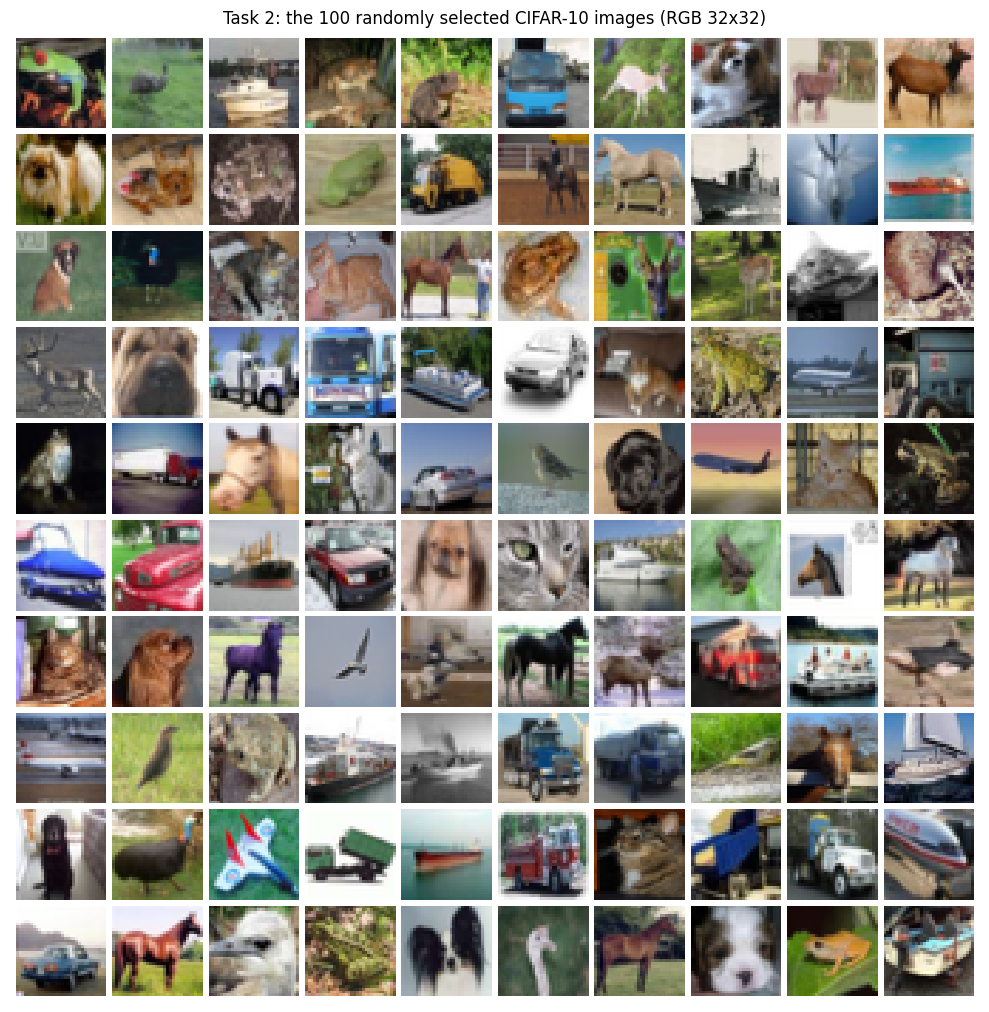

In [3]:
sel_gen = torch.Generator().manual_seed(T2_SEED)
# A dedicated random generator for the selection, so the selection does not depend on any other random calls.

t2_idx = torch.randperm(len(all_rgb), generator=sel_gen)[:T2_N_IMAGES]
# randperm shuffles the numbers 0..49999; keeping the first 100 gives 100 different, uniformly random indices.
# Shape: (100,). Each value is a CIFAR-10 index.

rgb_uint8 = all_rgb[t2_idx]
# The 100 selected images, shape (100, 3, 32, 32), dtype uint8 (values 0-255).

assert len(torch.unique(t2_idx)) == T2_N_IMAGES          # all 100 indices are different
assert rgb_uint8.shape == (T2_N_IMAGES, 3, 32, 32)       # RGB 32x32, as required
assert torch.equal(t2_idx, torch.randperm(len(all_rgb), generator=torch.Generator().manual_seed(T2_SEED))[:T2_N_IMAGES])
# Re-running the selection with the same seed must give exactly the same indices (reproducibility).

rgb_float = rgb_uint8.float() / 255.0
# Converts pixels to floats in [0, 1]. Shape stays (100, 3, 32, 32). Used for display and simple image statistics.

split_perm = torch.randperm(T2_N_IMAGES, generator=torch.Generator().manual_seed(T2_SEED + 1))
# A random order of the positions 0..99, used to split the images into train and held-out.
pos_train = split_perm[:T2_N_TRAIN].sort().values       # 80 image positions (0..99) used for training pairs
pos_test = split_perm[T2_N_TRAIN:].sort().values        # 20 image positions used only for held-out pairs

assert len(set(pos_train.tolist()) & set(pos_test.tolist())) == 0
# No image is in both sets, so held-out pairs contain only images never seen during training.

chan_mean = rgb_float[pos_train].mean(dim=(0, 2, 3), keepdim=True)
# Mean of each colour channel over the 80 training images only, shape (1, 3, 1, 1).
# Computed on training images only so that no information from held-out images is used.
chan_std = rgb_float[pos_train].std(dim=(0, 2, 3), keepdim=True)
# Standard deviation of each colour channel over the training images, shape (1, 3, 1, 1).

imgs_norm = (rgb_float - chan_mean) / chan_std
# Standardised images (roughly mean 0, std 1 per channel), shape (100, 3, 32, 32). This helps the CNNs train smoothly.

imgs_dev = imgs_norm.to(device)
# The 100 images are tiny (100*3*32*32 floats), so we keep all of them on the GPU/CPU device once
# and later pick pairs simply by indexing, instead of copying images for every batch.

print("selected CIFAR-10 indices:", t2_idx.tolist())
print("train images:", len(pos_train), "| held-out images:", len(pos_test))

grid = make_grid(rgb_float, nrow=10, padding=2, pad_value=1.0)
# Puts the 100 images into one 10x10 grid image, shape (3, H, W), with white borders between images.
plt.figure(figsize=(10, 10.4))                                       # square figure for the 10x10 grid
plt.imshow(grid.permute(1, 2, 0).numpy(), interpolation="nearest")   # matplotlib needs (H, W, 3)
plt.title("Task 2: the 100 randomly selected CIFAR-10 images (RGB 32x32)")
plt.axis("off")                                                      # no axes for an image grid
plt.tight_layout()                                                   # remove extra margins
plt.savefig(f"{OUT_DIR}/t2_selected_images.png", bbox_inches="tight")   # save for the report
plt.show()                                                           # display

## T2-4. Pair-generation strategy

For a set of images we take **every ordered pair (A, B) with A ≠ B**. This is what the sender observes.
Each ordered pair is used **twice**:
- once with the receiver getting `(A, B)` (same order, target 1),
- once with the receiver getting `(B, A)` (swapped, target 0).

So the data is exactly balanced (50% match, 50% mismatch). Because both (A, B) and (B, A) are sender orders too,
the receiver's images alone carry no information about the answer.

- training pairs: 80 x 79 ordered pairs x 2 = 12,640 examples
- held-out pairs: 20 x 19 ordered pairs x 2 = 760 examples, from 20 unseen images

training examples: 12640 | held-out examples: 760
share of 'match' examples: train 0.50, held-out 0.50


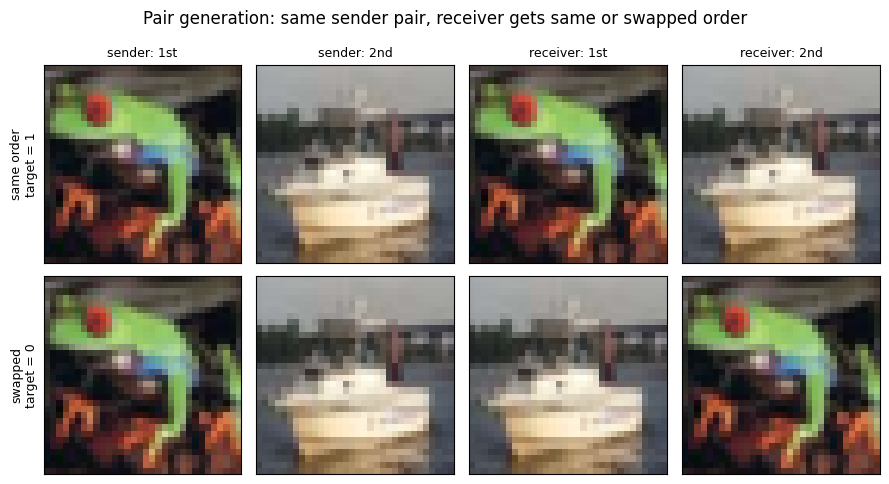

In [4]:
def make_pairs(positions):
    # Builds all ordered pairs of different images from `positions` (image positions 0..99).
    a, b = torch.meshgrid(positions, positions, indexing="ij")
    # a[i, j] = positions[i], b[i, j] = positions[j]: every combination of two images, shape (n, n) each.
    keep = a != b
    # Boolean mask (n, n): True where the two images are different (a pair of an image with itself is useless).
    ordered = torch.stack([a[keep], b[keep]], dim=1)
    # All ordered pairs (A, B) with A != B, shape (n*(n-1), 2). Column 0 = first image A, column 1 = second image B.
    pairs = ordered.repeat_interleave(2, dim=0)
    # Repeats every ordered pair twice in a row, shape (2*n*(n-1), 2): one copy for "same order", one for "swapped".
    swap = torch.arange(len(pairs)) % 2
    # 0, 1, 0, 1, ...: swap = 0 -> receiver gets (A, B); swap = 1 -> receiver gets (B, A). Exactly balanced.
    return pairs, swap

pairs_train, swap_train = make_pairs(pos_train)   # training examples from the 80 training images
pairs_test, swap_test = make_pairs(pos_test)      # held-out examples from the 20 unseen images

print("training examples:", len(pairs_train), "| held-out examples:", len(pairs_test))
print(f"share of 'match' examples: train {1 - swap_train.float().mean():.2f}, held-out {1 - swap_test.float().mean():.2f}")
# Both must be exactly 0.50 (balanced).

assert len(pairs_train) == T2_N_TRAIN * (T2_N_TRAIN - 1) * 2                     # 12,640
assert swap_train.float().mean() == 0.5 and swap_test.float().mean() == 0.5       # balanced
assert not set(pairs_train.flatten().tolist()) & set(pos_test.tolist())
# No held-out image appears anywhere in the training pairs.

fig, axes = plt.subplots(2, 4, figsize=(9, 5))
# Small illustration: one ordered pair, shown once with receiver order = same and once swapped.
ex_a, ex_b = pairs_train[0].tolist()       # the first training pair (image positions A and B)
rows = [("same order", ex_a, ex_b, 1), ("swapped", ex_b, ex_a, 0)]   # (description, receiver first, receiver second, target)
for r, (name, first, second, target) in enumerate(rows):
    for c, pos in enumerate([ex_a, ex_b, first, second]):
        # Columns: sender's A, sender's B, receiver's first image, receiver's second image.
        axes[r, c].imshow(rgb_float[pos].permute(1, 2, 0).numpy(), interpolation="nearest")   # (32, 32, 3) for matplotlib
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])                                  # hide tick marks
    axes[r, 0].set_ylabel(f"{name}\ntarget = {target}", fontsize=9)   # row label with the correct answer
for c, title in enumerate(["sender: 1st", "sender: 2nd", "receiver: 1st", "receiver: 2nd"]):
    axes[0, c].set_title(title, fontsize=9)                           # column titles
fig.suptitle("Pair generation: same sender pair, receiver gets same or swapped order")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/t2_pair_generation.png", bbox_inches="tight")
plt.show()

## T2-5. Sender model

Both images are stacked along the channel dimension: 3 + 3 = 6 channels, 32x32. A small CNN turns this into a
64-number feature vector, and a linear layer turns that into one number (the message logit). A batch-normalisation
layer on that number keeps the sender from getting stuck sending the same bit for every pair.
Stacking along channels keeps the order information: channels 0-2 are always the first image, 3-5 the second.

In [5]:
class PairEncoder(nn.Module):
    # Small CNN that maps an image pair (6, 32, 32) to a feature vector (T2_FEAT,).
    # The sender and the receiver each get their OWN PairEncoder (no shared weights).
    def __init__(self, out_features=T2_FEAT):
        super().__init__()                                  # initialise nn.Module internals
        self.net = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=3, padding=1),     # 16 filters over both images: (B, 6, 32, 32) -> (B, 16, 32, 32)
            nn.ReLU(),                                      # non-linearity max(0, x), shape unchanged
            nn.MaxPool2d(2),                                # keep the max of each 2x2 block: (B, 16, 32, 32) -> (B, 16, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),    # (B, 16, 16, 16) -> (B, 32, 16, 16)
            nn.ReLU(),                                      # non-linearity
            nn.MaxPool2d(2),                                # (B, 32, 16, 16) -> (B, 32, 8, 8)
            nn.Flatten(),                                   # (B, 32, 8, 8) -> (B, 2048), one long vector per pair
            nn.Linear(32 * 8 * 8, out_features),            # fully connected: (B, 2048) -> (B, 64)
            nn.ReLU(),                                      # non-linearity
        )

    def forward(self, first, second):
        # first, second: the two images of a pair in a given order, each (B, 3, 32, 32).
        pair = torch.cat([first, second], dim=1)            # stack along channels -> (B, 6, 32, 32); order is preserved
        return self.net(pair)                               # feature vector (B, 64)


class Sender(nn.Module):
    # S: looks at (A, B) in the order it observed them and produces ONE message logit per pair.
    def __init__(self):
        super().__init__()
        self.encoder = PairEncoder()                        # its own CNN for the image pair
        self.to_message = nn.Linear(T2_FEAT, 1)             # (B, 64) -> (B, 1): one number = the message logit
        self.norm = nn.BatchNorm1d(1)
        # Batch normalisation of the logit: during training it centres the logits of each batch around 0 (with a
        # learnable scale and shift). Without it, the sender can start (or drift) into sending the SAME bit for every
        # pair; the receiver then learns to ignore the bit and training gets stuck at 50%. Centring keeps both bit
        # values in use, so the receiver always gets a varying message it can learn from.
        # In evaluation mode it uses the running mean/std collected during training (no dependence on the batch).

    def forward(self, img_a, img_b):
        features = self.encoder(img_a, img_b)               # (B, 64) description of the ordered pair
        logit = self.norm(self.to_message(features))        # (B, 1): normalised message logit
        return logit.squeeze(1)                             # (B, 1) -> (B,): message logit (any real number)
        # sigmoid(logit) > 0.5 will become bit 1, otherwise bit 0 (see T2-7).

## T2-6. Receiver model

The receiver encodes the pair it received (in its own order) with its own small CNN, appends the one-bit message
(as -1 / +1) to the 64 image features, and a small fully connected classifier outputs the match logit.
The hidden layer is needed because the decision is like an XOR: "does what I see agree with the bit?".

In [6]:
class Receiver(nn.Module):
    # R: gets (first, second) in possibly swapped order plus the sender's bit, outputs a "match" logit.
    def __init__(self):
        super().__init__()
        self.encoder = PairEncoder()                        # its own CNN (separate weights from the sender)
        self.classifier = nn.Sequential(
            nn.Linear(T2_FEAT + 1, 64),                     # 64 image features + 1 message value -> 64 hidden units
            nn.ReLU(),                                      # non-linearity (makes XOR-like decisions possible)
            nn.Linear(64, 1),                               # -> 1 output: the match logit
        )

    def forward(self, first, second, message):
        # first, second: (B, 3, 32, 32) images in the receiver's order; message: (B,) bits (0 or 1).
        features = self.encoder(first, second)              # (B, 64) description of the received ordered pair
        msg = (2 * message - 1).unsqueeze(1)                # 0/1 -> -1/+1 (centred around 0), shape (B, 1)
        joint = torch.cat([features, msg], dim=1)           # image features + message, shape (B, 65)
        return self.classifier(joint).squeeze(1)            # match logit, shape (B,). sigmoid(logit) = P(match)

## T2-7. Communication / training mechanism

`send_bit` implements the noisy-sigmoid DRU described at the top of Task 2 (soft + noisy during training,
hard 0/1 bit during evaluation).
`run_system` runs one full round of communication for a batch of examples:
sender sees (A, B) -> bit m -> receiver sees (A, B) or (B, A) plus m -> match logit.

The **target** (match or not) is only used in the loss. It is never given to the sender or the receiver.

In [7]:
def send_bit(logit, training):
    # Turns the sender's logit (B,) into the transmitted message (B,).
    if training:
        noise = T2_NOISE * torch.randn_like(logit)
        # Gaussian noise N(0, T2_NOISE^2), one value per pair, same shape and device as the logit (B,).
        # It comes from PyTorch's seeded global generator, so it is reproducible.
        return torch.sigmoid(logit + noise)
        # DRU training message: a smooth value in (0, 1), so gradients flow back into the sender.
        # Because of the noise, only logits far from 0 give a reliable message, which pushes the sender
        # towards clear 0/1 decisions instead of hiding information in small differences.
    return (torch.sigmoid(logit) > 0.5).float()
    # Evaluation: a true one-bit message, 1 if sigmoid(logit) > 0.5 (i.e. logit > 0), otherwise 0. No noise.


def run_system(pairs, swap, training=False, tamper=None):
    # One communication round for a batch.
    # pairs: (B, 2) image positions (A, B) as the sender sees them; swap: (B,) 0 = receiver gets (A, B), 1 = gets (B, A).
    # tamper: None (normal), "flip" (invert the bit) or "zero" (always send 0). Only used for analysis in T2-10.
    pairs, swap = pairs.to(device), swap.to(device)          # move the indices to the same device as the images
    img_a = imgs_dev[pairs[:, 0]]                            # sender's first image A, (B, 3, 32, 32)
    img_b = imgs_dev[pairs[:, 1]]                            # sender's second image B, (B, 3, 32, 32)

    message = send_bit(sender(img_a, img_b), training)
    # Sender looks at (A, B) and emits one message per pair, (B,): noisy soft value when training, hard 0/1 bit otherwise.
    if tamper == "flip":
        message = 1 - message                                # analysis only: invert every bit
    elif tamper == "zero":
        message = torch.zeros_like(message)                  # analysis only: send no information

    flip = swap.bool().view(-1, 1, 1, 1)                     # (B, 1, 1, 1) so it broadcasts over channels and pixels
    first = torch.where(flip, img_b, img_a)                  # receiver's first image: B if swapped, else A
    second = torch.where(flip, img_a, img_b)                 # receiver's second image: A if swapped, else B

    logit = receiver(first, second, message)                 # receiver's match logit, (B,)
    target = 1.0 - swap.float()                              # 1 = same order (match), 0 = swapped (mismatch), (B,)
    return logit, target, message


@torch.no_grad()                                             # no gradients: pure evaluation
def evaluate_system(pairs, swap, tamper=None, batch=1024):
    # Runs the trained system on all given examples (hard bits) and returns predictions and metrics.
    sender.eval(); receiver.eval()                           # evaluation mode (good practice)
    logits, targets, messages = [], [], []                   # collected batch by batch
    for i in range(0, len(pairs), batch):                    # go through the examples in chunks
        lg, tg, ms = run_system(pairs[i:i + batch], swap[i:i + batch], training=False, tamper=tamper)
        logits.append(lg.cpu()); targets.append(tg.cpu()); messages.append(ms.cpu())   # keep results on CPU
    logits, targets, messages = torch.cat(logits), torch.cat(targets), torch.cat(messages)   # (N,) each
    preds = (logits > 0).float()                             # logit > 0 <=> sigmoid(logit) > 0.5 -> predict "match"
    return {
        "logits": logits, "targets": targets, "messages": messages, "preds": preds,
        "probs": torch.sigmoid(logits),                                          # P(match) for every example
        "loss": F.binary_cross_entropy_with_logits(logits, targets).item(),      # average BCE loss
        "accuracy": (preds == targets).float().mean().item(),                    # share of correct decisions
    }

# quick demonstration of the DRU on 3 made-up logits: a confident 0, an undecided value and a confident 1
torch.manual_seed(T2_SEED)                                         # fixed noise for the demo
demo_logit = torch.tensor([-6.0, 0.1, 6.0], requires_grad=True)    # three example sender logits
demo_train = send_bit(demo_logit, training=True)                   # noisy soft messages (training)
demo_train.sum().backward()                                        # gradients flow through the sigmoid
print("DRU demo  logits:                ", demo_logit.tolist())
print("          training messages:     ", [round(v, 3) for v in demo_train.tolist()])
# Confident logits (-6, +6) stay close to 0 and 1 despite the noise; the undecided logit (0.1) becomes a random-looking value.
print("          evaluation bits:       ", send_bit(demo_logit.detach(), training=False).tolist())   # hard 0/1 bits
print("          gradients (training):  ", [round(g, 4) for g in demo_logit.grad.tolist()])
# Non-zero gradients: the sender can learn from the receiver's loss.

DRU demo  logits:                 [-6.0, 0.10000000149011612, 6.0]
          training messages:      [0.003, 0.557, 0.998]
          evaluation bits:        [0.0, 1.0, 1.0]
          gradients (training):   [0.0034, 0.2468, 0.002]


## T2-8. Training loop

Sender and receiver are trained **jointly, end to end** with one Adam optimizer and binary cross-entropy on the
receiver's match prediction. The loss gradient flows from the receiver back through the (noisy, smooth) message
into the sender. All settings are fixed in advance; the model after the last epoch is used.

The training loss/accuracy are measured with the noisy training messages; the held-out curve and all final results
(T2-10) use hard 0/1 bits.

The held-out loss/accuracy is recorded after each epoch **only to draw the curve**. It is never used to choose
epochs, settings or models.

Don't worry if the loss stays near 0.693 (= ln 2, chance level) for the first few epochs: at the start the sender's
bit carries no information, so the receiver can only guess. Once the two networks start to agree on a convention,
the loss drops quickly. This is the usual "symmetry-breaking" phase of communication games.

In [8]:
seed_all(T2_SEED)                       # reseed so both networks start from the same weights in every run
sender = Sender().to(device)            # create the sender and move its weights to the device
receiver = Receiver().to(device)        # create the receiver and move its weights to the device

optimizer_t2 = torch.optim.Adam(list(sender.parameters()) + list(receiver.parameters()), lr=T2_LR)
# One Adam optimizer for BOTH networks, so they are updated together (joint end-to-end training).

n_sender = sum(p.numel() for p in sender.parameters())       # number of sender weights
n_receiver = sum(p.numel() for p in receiver.parameters())   # number of receiver weights
print(sender)
print(receiver)
print(f"parameters: sender {n_sender:,}, receiver {n_receiver:,}")

shuffle_gen = torch.Generator().manual_seed(T2_SEED + 4)     # seeded generator for the batch order each epoch
steps_per_epoch_t2 = math.ceil(len(pairs_train) / T2_BATCH)  # number of mini-batches per epoch (50)
t2_hist = {"train_loss": [], "train_acc": [], "heldout_loss": [], "heldout_acc": []}   # learning curves

t0 = time.time()                                             # start the timer
for epoch in range(1, T2_EPOCHS + 1):                        # loop over epochs
    sender.train(); receiver.train()                         # training mode for both networks
    order_t2 = torch.randperm(len(pairs_train), generator=shuffle_gen)   # new random order of the 12,640 examples
    loss_sum, correct, seen = 0.0, 0.0, 0                     # running totals for this epoch

    for i in range(0, len(order_t2), T2_BATCH):              # go through the examples in mini-batches
        batch_idx = order_t2[i:i + T2_BATCH]                 # indices of this batch's examples, (B,)
        logit, target, _ = run_system(pairs_train[batch_idx], swap_train[batch_idx], training=True)
        # Full communication round with noisy DRU messages: logit and target have shape (B,).

        loss = F.binary_cross_entropy_with_logits(logit, target)
        # Binary cross-entropy between the receiver's match logit and the true match label (1 = same order).
        # The "with_logits" version applies the sigmoid internally in a numerically stable way.

        optimizer_t2.zero_grad()                             # clear gradients from the previous step
        loss.backward()                                      # gradients for receiver AND sender (through the message)
        optimizer_t2.step()                                  # update both networks

        loss_sum += loss.item() * len(batch_idx)             # weight by batch size for a correct epoch average
        correct += ((logit > 0).float() == target).sum().item()   # correct decisions in this batch (with noisy messages)
        seen += len(batch_idx)                               # number of examples processed

    held = evaluate_system(pairs_test, swap_test)            # monitoring only, not used for any decision
    t2_hist["train_loss"].append(loss_sum / seen)            # average training loss of the epoch
    t2_hist["train_acc"].append(correct / seen)              # running training accuracy of the epoch
    t2_hist["heldout_loss"].append(held["loss"])             # held-out loss after the epoch
    t2_hist["heldout_acc"].append(held["accuracy"])          # held-out accuracy after the epoch

    if epoch == 1 or epoch % 5 == 0:                         # progress report every 5 epochs
        print(f"epoch {epoch:2d} | train loss {loss_sum / seen:.4f} acc {correct / seen:.3f} | "
              f"held-out loss {held['loss']:.4f} acc {held['accuracy']:.3f} | {time.time() - t0:.0f}s")

print(f"training finished in {time.time() - t0:.0f}s")
torch.save({"sender": sender.state_dict(), "receiver": receiver.state_dict()}, f"{OUT_DIR}/t2_sender_receiver.pt")
# Saves the final weights of both networks.
pd.DataFrame(t2_hist).rename_axis("epoch").to_csv(f"{OUT_DIR}/t2_history.csv")   # saves the learning curves

Sender(
  (encoder): PairEncoder(
    (net): Sequential(
      (0): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
      (7): Linear(in_features=2048, out_features=64, bias=True)
      (8): ReLU()
    )
  )
  (to_message): Linear(in_features=64, out_features=1, bias=True)
  (norm): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Receiver(
  (encoder): PairEncoder(
    (net): Sequential(
      (0): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stri

## T2-9. Loss plot

The training curves are measured with the **noisy** DRU messages, which make the receiver's job harder, so they
usually look worse than the held-out curves, which use clean hard bits. This is expected, not a sign of a problem.
The fair train vs held-out comparison (both with hard bits) is the table in T2-11.

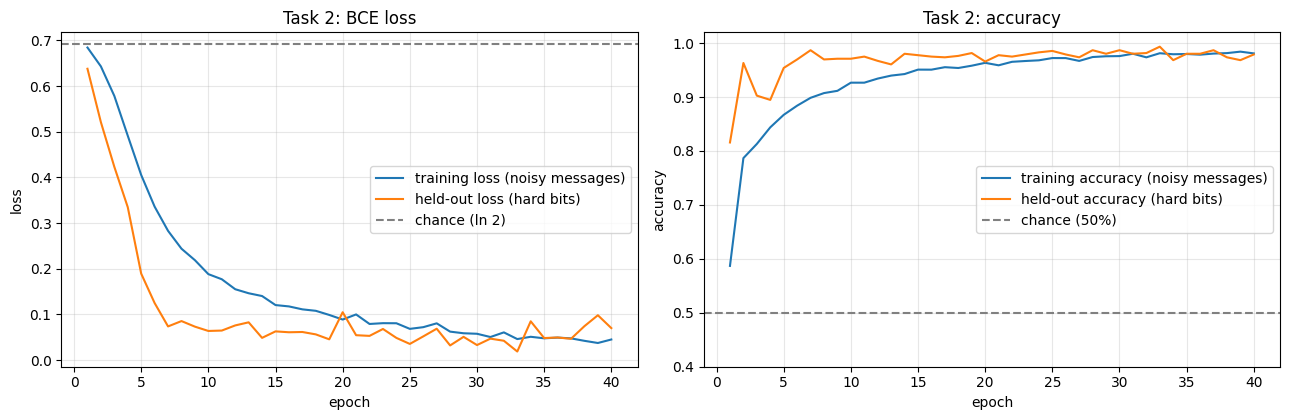

In [9]:
ep = range(1, T2_EPOCHS + 1)                                  # x-axis: epoch numbers
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))             # loss on the left, accuracy on the right
axes[0].plot(ep, t2_hist["train_loss"], label="training loss (noisy messages)")   # training BCE per epoch
axes[0].plot(ep, t2_hist["heldout_loss"], label="held-out loss (hard bits)")      # held-out BCE per epoch
axes[0].axhline(math.log(2), color="gray", ls="--", label="chance (ln 2)")
# ln 2 = 0.693 is the BCE of always answering 0.5, i.e. a receiver that gets no useful information.
axes[0].set(title="Task 2: BCE loss", xlabel="epoch", ylabel="loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, t2_hist["train_acc"], label="training accuracy (noisy messages)")   # running training accuracy
axes[1].plot(ep, t2_hist["heldout_acc"], label="held-out accuracy (hard bits)")      # held-out accuracy
axes[1].axhline(0.5, color="gray", ls="--", label="chance (50%)")      # what the receiver gets without the message
axes[1].set(title="Task 2: accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0.4, 1.02))
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/t2_loss_curve.png", bbox_inches="tight")
plt.show()

## T2-10. Evaluation

Final evaluation with **hard bits** (threshold 0.5) on all training examples (the required training error) and on
the held-out examples from the 20 unseen images.

Two extra checks show that the receiver really relies on the message:
- **flipped message**: invert every bit; if the receiver uses the bit, accuracy should drop far below 50%;
- **no message** (always 0): accuracy should fall to about 50%, because the images alone do not reveal the answer.

In [10]:
res_train = evaluate_system(pairs_train, swap_train)                     # all 12,640 training examples
res_test = evaluate_system(pairs_test, swap_test)                        # all 760 held-out examples
res_train_flip = evaluate_system(pairs_train, swap_train, tamper="flip")   # training examples, inverted bits
res_test_flip = evaluate_system(pairs_test, swap_test, tamper="flip")      # held-out examples, inverted bits
res_train_zero = evaluate_system(pairs_train, swap_train, tamper="zero")   # training examples, no information sent
res_test_zero = evaluate_system(pairs_test, swap_test, tamper="zero")      # held-out examples, no information sent

train_error_t2 = 1 - res_train["accuracy"]      # required: training-set error rate
test_error_t2 = 1 - res_test["accuracy"]        # held-out error rate

# sender bit for EVERY ordered pair of the 100 images, as a 100 x 100 matrix: M[i, j] = bit sent for (i, j)
with torch.no_grad():
    sender.eval()                                                         # evaluation mode
    ii, jj = torch.meshgrid(torch.arange(T2_N_IMAGES), torch.arange(T2_N_IMAGES), indexing="ij")   # all (i, j) combinations
    all_logits = torch.cat([sender(imgs_dev[ii.flatten()[k:k + 1000]], imgs_dev[jj.flatten()[k:k + 1000]]).cpu()
                            for k in range(0, T2_N_IMAGES ** 2, 1000)])  # sender logits for 10,000 ordered pairs, in chunks
    M = (torch.sigmoid(all_logits) > 0.5).float().view(T2_N_IMAGES, T2_N_IMAGES)   # hard bits, shape (100, 100)

def order_sensitivity(positions):
    # Share of unordered pairs {A, B} for which the sender sends DIFFERENT bits for (A, B) and (B, A).
    # Only these pairs can be decoded correctly; if both orders give the same bit, the receiver can only guess.
    a, b = torch.meshgrid(positions, positions, indexing="ij")   # all combinations
    upper = a < b                                                 # each unordered pair once
    return (M[a[upper], b[upper]] != M[b[upper], a[upper]]).float().mean().item()

sens_train = order_sensitivity(pos_train)    # on the training images
sens_test = order_sensitivity(pos_test)      # on the held-out images

print(f"training error rate: {train_error_t2:.4f}  (accuracy {res_train['accuracy']:.4f})")
print(f"held-out error rate: {test_error_t2:.4f}  (accuracy {res_test['accuracy']:.4f})")
print(f"sender gives different bits for the two orders: train {100 * sens_train:.1f}% of pairs, held-out {100 * sens_test:.1f}%")

training error rate: 0.0093  (accuracy 0.9907)
held-out error rate: 0.0211  (accuracy 0.9789)
sender gives different bits for the two orders: train 98.9% of pairs, held-out 96.3%


## T2-11. Results table

In [11]:
t2_results = pd.DataFrame({
    "examples": [len(pairs_train), len(pairs_test)],                                # number of evaluated examples
    "accuracy": [res_train["accuracy"], res_test["accuracy"]],                      # correct match/mismatch decisions
    "error rate": [train_error_t2, test_error_t2],                                  # 1 - accuracy
    "BCE loss": [res_train["loss"], res_test["loss"]],                              # average binary cross-entropy
    "acc. flipped bit": [res_train_flip["accuracy"], res_test_flip["accuracy"]],    # check: receiver uses the bit
    "acc. no message": [res_train_zero["accuracy"], res_test_zero["accuracy"]],     # check: images alone -> ~50%
    "order-sensitive pairs": [sens_train, sens_test],                               # sender distinguishes the 2 orders
}, index=["training pairs (80 images)", "held-out pairs (20 unseen images)"])
display(t2_results.round(4))                                   # concise results table
t2_results.to_csv(f"{OUT_DIR}/t2_results.csv")                 # save it for the report

,examples,accuracy,error rate,BCE loss,acc. flipped bit,acc. no message,order-sensitive pairs
training pairs (80 images),12640,0.9907,0.0093,0.0236,0.0093,0.5,0.9886
held-out pairs (20 unseen images),760,0.9789,0.0211,0.0700,0.0211,0.5,0.9632


## T2-12. Communication protocol examples

For a few held-out pairs we show what the sender sends for each order and how the receiver decides.
**The meaning of the bit is arbitrary:** the networks may have agreed that 1 means "A first" for some kind of image
pair and 0 for another. What matters is only that the sender gives *different* bits for (A, B) and (B, A) and that
the receiver interprets them the same way. Nobody told them that 0 should mean "A before B".

To see whether the protocol resembles a simple human rule, we also check how often the bit agrees with rules like
"send 1 if the first image is brighter". These image statistics are used only for this analysis, never in training.

,"pair (CIFAR idx A, B)",sender input order,sender message,R gets same order: P(match),R gets swapped: P(match),both correct
0,"20165, 42186","(A,B)",0,1.000,0.000,True
1,"20165, 42186","(B,A)",1,1.000,0.000,True
2,"6899, 17004","(A,B)",1,1.000,0.000,True
3,"6899, 17004","(B,A)",0,1.000,0.000,True
4,"39339, 42872","(A,B)",1,1.000,0.000,True
5,"39339, 42872","(B,A)",0,1.000,0.000,True
6,"20844, 43759","(A,B)",0,1.000,0.000,True
7,"20844, 43759","(B,A)",1,1.000,0.000,True
8,"43777, 47718","(A,B)",0,1.000,0.000,True
9,"43777, 47718","(B,A)",1,1.000,0.000,True


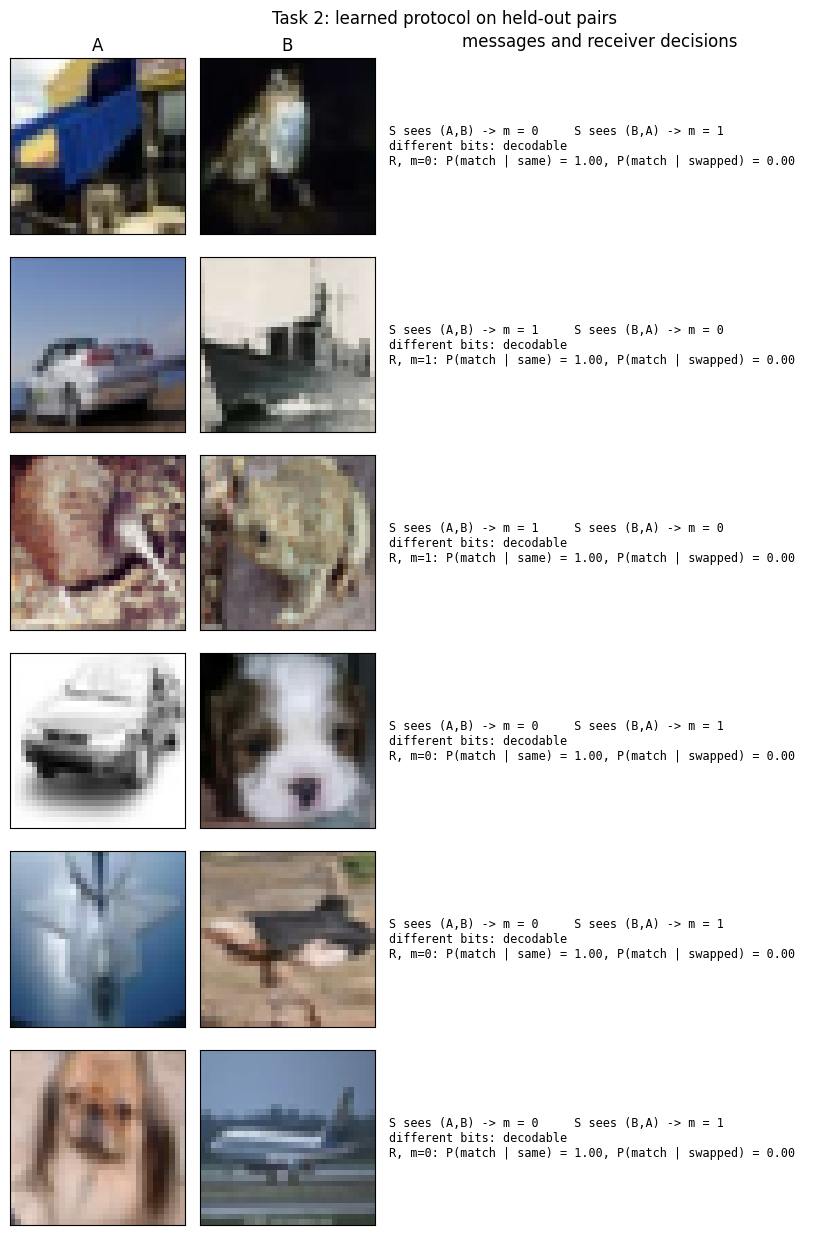

,rule,agreement,best of rule / inverted rule
3,1 if blue(A) > blue(B),0.158,0.842
0,1 if brightness(A) > brightness(B),0.162,0.838
2,1 if green(A) > green(B),0.209,0.791
1,1 if red(A) > red(B),0.256,0.744
4,1 if contrast(A) > contrast(B),0.353,0.647


share of messages equal to 1: 0.490


In [12]:
example_gen = torch.Generator().manual_seed(T2_SEED + 20)                 # seeded choice of examples
ex_pos = pos_test[torch.randperm(len(pos_test), generator=example_gen)[:12]].view(6, 2)
# 6 random pairs of held-out images (positions), shape (6, 2): column 0 = A, column 1 = B.

rows_t2 = []                                                              # rows of the protocol table
for a, b in ex_pos.tolist():                                              # each example pair
    for s_first, s_second, s_order in [(a, b, "(A,B)"), (b, a, "(B,A)")]:   # the sender sees both orders
        r = evaluate_system(torch.tensor([[s_first, s_second]] * 2), torch.tensor([0, 1]))
        # Two examples for this sender order: receiver gets the same order (swap 0) and the swapped order (swap 1).
        rows_t2.append({
            "pair (CIFAR idx A, B)": f"{t2_idx[a].item()}, {t2_idx[b].item()}",   # identifies the two images
            "sender input order": s_order,                                       # what the sender saw
            "sender message": int(r["messages"][0].item()),                      # the bit it sent
            "R gets same order: P(match)": round(r["probs"][0].item(), 3),       # should be close to 1
            "R gets swapped: P(match)": round(r["probs"][1].item(), 3),          # should be close to 0
            "both correct": bool((r["preds"] == r["targets"]).all().item()),     # did the receiver get both right?
        })
protocol_table = pd.DataFrame(rows_t2)
display(protocol_table)                                         # table "Sender input order | Sender message | ..."
protocol_table.to_csv(f"{OUT_DIR}/t2_protocol_examples.csv", index=False)

fig, axes = plt.subplots(len(ex_pos), 3, figsize=(9, 2.1 * len(ex_pos)), gridspec_kw={"width_ratios": [1, 1, 2.4]})
# One row per example pair: image A | image B | text with the messages and receiver decisions.
for r, (a, b) in enumerate(ex_pos.tolist()):
    axes[r, 0].imshow(rgb_float[a].permute(1, 2, 0).numpy(), interpolation="nearest")   # image A
    axes[r, 1].imshow(rgb_float[b].permute(1, 2, 0).numpy(), interpolation="nearest")   # image B
    m_ab, m_ba = int(M[a, b].item()), int(M[b, a].item())          # bits for (A, B) and (B, A)
    sub = protocol_table.iloc[2 * r: 2 * r + 2]                    # the two table rows of this pair
    text = (f"S sees (A,B) -> m = {m_ab}     S sees (B,A) -> m = {m_ba}\n"
            f"{'different bits: decodable' if m_ab != m_ba else 'SAME bit for both orders: not decodable'}\n"
            f"R, m={m_ab}: P(match | same) = {sub.iloc[0]['R gets same order: P(match)']:.2f}, "
            f"P(match | swapped) = {sub.iloc[0]['R gets swapped: P(match)']:.2f}")
    axes[r, 2].text(0.0, 0.5, text, va="center", fontsize=8.5, family="monospace")   # the explanation text
    for ax in axes[r]:
        ax.set_xticks([]); ax.set_yticks([])                       # no ticks
    axes[r, 2].axis("off")                                         # the text panel needs no frame
axes[0, 0].set_title("A"); axes[0, 1].set_title("B"); axes[0, 2].set_title("messages and receiver decisions")
fig.suptitle("Task 2: learned protocol on held-out pairs")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/t2_protocol_examples.png", bbox_inches="tight")
plt.show()

# Does the bit follow a simple human-readable rule? Compare with "1 if feature(A) > feature(B)" for a few features.
features = {
    "brightness": rgb_float.mean(dim=(1, 2, 3)),                   # mean pixel value of each image, (100,)
    "red": rgb_float[:, 0].mean(dim=(1, 2)),                       # mean of the red channel
    "green": rgb_float[:, 1].mean(dim=(1, 2)),                     # mean of the green channel
    "blue": rgb_float[:, 2].mean(dim=(1, 2)),                      # mean of the blue channel
    "contrast": rgb_float.std(dim=(1, 2, 3)),                      # pixel standard deviation of each image
}
pa, pb = torch.meshgrid(torch.arange(T2_N_IMAGES), torch.arange(T2_N_IMAGES), indexing="ij")
off_diag = pa != pb                                                # all ordered pairs of different images
rule_rows = []
for name, f in features.items():
    rule_bit = (f[pa[off_diag]] > f[pb[off_diag]]).float()         # what the simple rule would send
    agree = (rule_bit == M[pa[off_diag], pb[off_diag]]).float().mean().item()   # how often the sender agrees
    rule_rows.append({"rule": f"1 if {name}(A) > {name}(B)", "agreement": agree,
                      "best of rule / inverted rule": max(agree, 1 - agree)})
    # Because the bit's meaning is arbitrary, agreement close to 0 is just as interesting as close to 1
    # (it means the inverted rule), so we also report max(agree, 1 - agree).
rule_table = pd.DataFrame(rule_rows).sort_values("best of rule / inverted rule", ascending=False)
display(rule_table.round(3))
rule_table.to_csv(f"{OUT_DIR}/t2_rule_agreement.csv", index=False)

bit_share = M[off_diag.view(T2_N_IMAGES, T2_N_IMAGES)].mean().item()   # how often bit 1 is sent overall
print(f"share of messages equal to 1: {bit_share:.3f}")

## T2-13. Analysis and conclusions

The text below is generated from the results of this run.

In [13]:
def t2_report(title, text):
    # Prints a titled section with wrapped lines.
    print("\n" + title)
    print("-" * len(title))
    for line in text.strip().split("\n"):
        print(textwrap.fill(line, 100))

test_pairs_t = pairs_test                                          # (760, 2) held-out sender pairs
sens_per_example = (M[test_pairs_t[:, 0], test_pairs_t[:, 1]] != M[test_pairs_t[:, 1], test_pairs_t[:, 0]])
# For each held-out example: True if the sender's bits for the two orders of its pair differ.
wrong = res_test["preds"] != res_test["targets"]                   # held-out examples the system got wrong
err_sensitive = wrong[sens_per_example].float().mean().item() if sens_per_example.any() else float("nan")
err_insensitive = wrong[~sens_per_example].float().mean().item() if (~sens_per_example).any() else float("nan")
# Error rate on pairs where the sender distinguished the orders vs. pairs where it did not.

best_rule = rule_table.iloc[0]                                     # simple rule that best matches the bit
gap_t2 = test_error_t2 - train_error_t2                            # how much worse on unseen images

if res_train["accuracy"] > 0.9:
    protocol_text = (f"Yes. On the training pairs the receiver is correct {100 * res_train['accuracy']:.1f}% of the time "
                     f"(training error rate {100 * train_error_t2:.2f}%), far above the 50% that is possible without the "
                     f"message. Flipping every bit drops accuracy to {100 * res_train_flip['accuracy']:.1f}% and sending no "
                     f"information gives {100 * res_train_zero['accuracy']:.1f}%, so the receiver really decodes the bit.")
elif res_train["accuracy"] > 0.6:
    protocol_text = (f"Partly. Training accuracy is {100 * res_train['accuracy']:.1f}% (error rate {100 * train_error_t2:.2f}%): "
                     f"better than chance, so some information is transmitted, but the protocol is not reliable for all pairs.")
else:
    protocol_text = (f"No. Training accuracy is only {100 * res_train['accuracy']:.1f}% (error rate {100 * train_error_t2:.2f}%), "
                     f"close to the 50% chance level, so the two networks did not agree on a usable protocol in this run.")

if res_train["accuracy"] <= 0.6:
    gen_text = (f"Not meaningful in this run: no protocol was learned on the training pairs, so the held-out error rate "
                f"({100 * test_error_t2:.2f}%) is also at chance level.")
elif abs(gap_t2) < 0.03:
    gen_text = (f"On pairs built from the 20 unseen images the error rate is {100 * test_error_t2:.2f}%, close to the training "
                f"error, so the protocol transfers well to new images.")
else:
    gen_text = (f"On pairs built from the 20 unseen images the error rate is {100 * test_error_t2:.2f}% vs "
                f"{100 * train_error_t2:.2f}% on training pairs, so the protocol works {'less' if gap_t2 > 0 else 'more'} "
                f"reliably on new images.")
gen_text += (f" The held-out set has only {len(pairs_test)} examples from 20 images ({len(pos_test) * (len(pos_test) - 1) // 2} "
             f"distinct image pairs), so this estimate is rough.")

if res_train["accuracy"] <= 0.6:                                   # no protocol learned -> nothing to interpret
    semantics_text = ("There is no learned protocol to interpret in this run: the sender did not send different bits for "
                      "the two orders, so the bit has no meaning.")
elif best_rule["best of rule / inverted rule"] > 0.9:
    semantics_text = (f"The bit agrees with the simple rule '{best_rule['rule']}' (or its inverse) for "
                      f"{100 * best_rule['best of rule / inverted rule']:.1f}% of ordered pairs, so the learned protocol is close "
                      f"to a human-interpretable rule such as comparing a simple property of the two images. The networks "
                      f"were never told to use this; they found it on their own.")
else:
    semantics_text = (f"The best simple rule ('{best_rule['rule']}') matches the bit only "
                      f"{100 * best_rule['best of rule / inverted rule']:.1f}% of the time, so the protocol is not a simple "
                      f"human rule like 'brighter image first'. It is a consistent internal convention shared by the two "
                      f"networks.")
semantics_text += (" In any case the meaning of 0 and 1 is arbitrary: the bit only has to be different for the two "
                   "orders and decoded the same way by the receiver.")

def pct_or_none(value):
    # Formats an error rate as a percentage, or explains that there were no such pairs (instead of printing "nan%").
    return "n/a (no such pairs)" if math.isnan(value) else f"{100 * value:.1f}%"

t2_report("Task 2 results", f"""
Training-set error rate: {100 * train_error_t2:.2f}%  (accuracy {100 * res_train['accuracy']:.2f}%, {len(pairs_train)} examples)
Held-out error rate:     {100 * test_error_t2:.2f}%  (accuracy {100 * res_test['accuracy']:.2f}%, {len(pairs_test)} examples from unseen images)
""")

t2_report("Why one bit is enough", """
A pair of images can only be in two orders, (A, B) or (B, A). Telling two possibilities apart needs log2(2) = 1 bit, so a single binary message is in principle sufficient: the sender only has to send different bits for the two orders, and the receiver has to check whether the bit fits the order it received.
""")

t2_report("Did S and R learn an effective protocol?", protocol_text)

t2_report("Generalization to unseen image pairs", gen_text)

t2_report("Failure cases", f"""
The sender sent different bits for the two orders in {100 * sens_train:.1f}% of training pairs and {100 * sens_test:.1f}% of held-out pairs. When it sends the same bit for (A, B) and (B, A), the receiver cannot know the order and can at best guess. On held-out examples the error rate was {pct_or_none(err_sensitive)} for pairs with different bits and {pct_or_none(err_insensitive)} for pairs with the same bit.
Typical difficult cases are pairs of very similar images (e.g. similar brightness or colour), where whatever image property the networks compare is almost equal, so a small change can flip the bit. With only 100 images the networks may also rely on properties that do not hold for new images.
""")

t2_report("Interpretable semantics?", semantics_text)

t2_report("Limitations", f"""
Only 100 images and one random seed were used; the held-out estimate comes from 20 images. The sender only ever has to distinguish two orders, so this is a very small communication problem; results could differ with other images, seeds or architectures.
""")


Task 2 results
--------------
Training-set error rate: 0.93%  (accuracy 99.07%, 12640 examples)
Held-out error rate:     2.11%  (accuracy 97.89%, 760 examples from unseen images)

Why one bit is enough
---------------------
A pair of images can only be in two orders, (A, B) or (B, A). Telling two possibilities apart needs
log2(2) = 1 bit, so a single binary message is in principle sufficient: the sender only has to send
different bits for the two orders, and the receiver has to check whether the bit fits the order it
received.

Did S and R learn an effective protocol?
----------------------------------------
Yes. On the training pairs the receiver is correct 99.1% of the time (training error rate 0.93%),
far above the 50% that is possible without the message. Flipping every bit drops accuracy to 0.9%
and sending no information gives 50.0%, so the receiver really decodes the bit.

Generalization to unseen image pairs
------------------------------------
On pairs built from the 20 unsee